# 07 — Khulna precipitation downscaling: PROJ-FREE FULL FINAL v3 — ORDERED

This notebook is rebuilt to solve the errors you showed:

1. **No `rasterio.warp.reproject()`** is used for the final maps, so the broken local PROJ database does not block the workflow.
2. It uses the fact confirmed by your `resolution_QA.csv`: all monthly precipitation rasters, NDVI, LST, DEM and Distance-to-Sea are already geographic WGS84 layers.
3. `SLOPE` and `ASPECT` are intentionally excluded from the paper-style land combination because your QA shows they are in UTM 45N and would require the broken PROJ installation. The reference paper's land variables are elevation, NDVI, LST and distance from sea, so this also matches the paper better.
4. The 16.67% station missingness is treated as an **edge-coverage problem**: if a station is only slightly outside a cropped raster, the nearest edge pixel is used. Exact NoData pixels also use the nearest valid cell.
5. No whole 2022 monthly raster is silently replaced by a median.
6. Monthly output paths are tracked in memory, so the annual section cannot accidentally look in the wrong folder and report `0/12`.
7. All final TIFFs are masked to the Khulna boundary.
8. The **annual rainfall panel is the final analytical output**, matching your requested paper order.

Default output grid: **0.005 degree (~500–550 m)**. This is a statistical downscaling grid. The source monthly raster resolution is about 0.008983 degree (~1 km), while DEM is finer.


In [1]:
# Packages used here.
# If scipy is missing:
# %pip install scipy


In [2]:
from pathlib import Path
from collections import OrderedDict
import re, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import rasterio
from rasterio.transform import from_origin
from rasterio.features import geometry_mask

import geopandas as gpd
from scipy.ndimage import map_coordinates, distance_transform_edt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
import joblib

RANDOM_STATE = 42
NODATA = -9999.0
TARGET_RES_DEG = 0.005
FIG_DPI = 600
EDGE_CLAMP_DEG = 0.075   # allow a station up to ~8 km outside a cropped source raster
NEARBY_RADIUS = 6

TRAIN_YEARS = [2017, 2018, 2019, 2020]
VALID_YEARS = [2021]
TEST_YEARS = [2022]
TEST_YEAR = 2022

mpl.rcParams.update({
    "font.family":"serif",
    "font.size":8,
    "axes.titlesize":8,
    "axes.labelsize":7,
    "xtick.labelsize":6,
    "ytick.labelsize":6,
})


In [3]:
def find_project_root(start=None):
    cur=(Path(start) if start else Path.cwd()).resolve()
    for p in [cur,*cur.parents]:
        if (p/"data").exists():
            return p
    raise FileNotFoundError("Project root not found. Put this notebook inside the repository.")

PROJECT_ROOT=find_project_root()
DATA_DIR=PROJECT_ROOT/"data"
RAW_DIR=DATA_DIR/"raw"
INTERIM_DIR=DATA_DIR/"interim"
PROCESSED_DIR=DATA_DIR/"processed"

ALIGNED_ROOT=PROCESSED_DIR/"aligned_rasters"
PRECIP_ROOT=ALIGNED_ROOT/"precipitation"
PRED_ROOT=ALIGNED_ROOT/"predictors"
RAW_PRED_ROOT=RAW_DIR/"predictors"

OUT_ROOT=PROJECT_ROOT/"outputs"/"paper_style_proj_free_final"
TABLE_DIR=OUT_ROOT/"tables"
FIG_DIR=OUT_ROOT/"figures"
MAP_DIR=OUT_ROOT/"monthly_masked_highres_tif"
ANNUAL_DIR=OUT_ROOT/"annual_masked_highres_tif"
QA_DIR=OUT_ROOT/"quality_control"
MODEL_DIR=PROJECT_ROOT/"models"/"paper_style_proj_free_final"

for p in [TABLE_DIR,FIG_DIR,MAP_DIR,ANNUAL_DIR,QA_DIR,MODEL_DIR]:
    p.mkdir(parents=True,exist_ok=True)

print("PROJECT_ROOT:",PROJECT_ROOT)
print("OUTPUT:",OUT_ROOT)


PROJECT_ROOT: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh
OUTPUT: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final


## 1. Detect datasets and build exact 2017–2022 monthly index


In [4]:
def norm_name(x):
    return re.sub(r"[^A-Z0-9]+","_",str(x).upper()).strip("_")

ALIASES={
    "PERSIANN_CDR":"CDR",
    "PERSIANNCDR":"CDR",
    "PERSIANN_CCS":"CCS",
    "PDIR_NOW":"PDIR",
    "GSMAP_GAUGE_V7":"GSMAP_GAUGE",
    "GSMAP_GAUGE":"GSMAP_GAUGE",
    "GSMAP_MVK_V7":"GSMAP_MVK",
    "GSMAP_MVK":"GSMAP_MVK",
    "ERA5_TIFF":"ERA5",
    "CHIRPS_TIFF_2017_2022":"CHIRPS",
    "IMERG_MONTHLY":"IMERG",
    "LST_DAYTIME":"LST_DAY",
    "DISTANCE_TO_SEA":"DIST_SEA",
    "DISTANCE_SEA":"DIST_SEA",
    "ELEVATION":"DEM",
}

def canonical(x):
    n=norm_name(x)
    return ALIASES.get(n,n)

def all_tifs(folder):
    if folder is None or not Path(folder).exists():
        return []
    z=[]
    for pat in ["*.tif","*.tiff","*.TIF","*.TIFF"]:
        z.extend(Path(folder).rglob(pat))
    return sorted(set(z))

def folder_map(root):
    d={}
    if root.exists():
        for p in root.iterdir():
            if p.is_dir():
                d[canonical(p.name)]=p
    return d

precip_folders=folder_map(PRECIP_ROOT)
predictor_folders=folder_map(PRED_ROOT)
raw_predictor_folders=folder_map(RAW_PRED_ROOT)

def extract_ym(path):
    s=Path(path).stem
    m=re.search(r"(?<!\d)(20\d{2})[^0-9]+(0?[1-9]|1[0-2])(?!\d)",s)
    if m:return int(m.group(1)),int(m.group(2))
    m=re.search(r"(?<!\d)(20\d{2})(0[1-9]|1[0-2])(?!\d)",s)
    if m:return int(m.group(1)),int(m.group(2))
    return None

def month_index(folder):
    d={}
    for p in all_tifs(folder):
        ym=extract_ym(p)
        if ym is not None:
            d.setdefault(ym,p)
    return d

precip_index={k:month_index(v) for k,v in precip_folders.items()}
predictor_index={k:month_index(v) for k,v in predictor_folders.items()}

def monthly_path(name,year,month):
    key=(int(year),int(month))
    if name in precip_index:return precip_index[name].get(key)
    if name in predictor_index:return predictor_index[name].get(key)
    return None

rows=[]
for name,idx in {**precip_index,**predictor_index}.items():
    rows.append({
        "dataset":name,
        "n_months":len(idx),
        "first":str(min(idx)) if idx else "",
        "last":str(max(idx)) if idx else "",
        "has_all_2022":all((2022,m) in idx for m in range(1,13))
    })
file_index=pd.DataFrame(rows)
display(file_index)
file_index.to_csv(QA_DIR/"monthly_file_index_QA.csv",index=False)


,dataset,n_months,first,last,has_all_2022
0,CCS,72,"(2017, 1)","(2022, 12)",True
1,CDR,72,"(2017, 1)","(2022, 12)",True
2,CHIRPS,72,"(2017, 1)","(2022, 12)",True
3,ERA5,72,"(2017, 1)","(2022, 12)",True
4,GSMAP_GAUGE,72,"(2017, 1)","(2022, 12)",True
5,GSMAP_MVK,72,"(2017, 1)","(2022, 12)",True
6,IMERG,72,"(2017, 1)","(2022, 12)",True
7,PDIR,72,"(2017, 1)","(2022, 12)",True
8,PERSIANN,72,"(2017, 1)","(2022, 12)",True
9,ASPECT,0,,,False


## 2. Use only paper-compatible land variables that do not require reprojection


In [5]:
# Paper-compatible land inputs:
# elevation, NDVI, LST, distance from sea.
MONTHLY_LAND=[x for x in ["NDVI","LST_DAY"] if x in predictor_folders]

def choose_static_wgs84(name):
    candidates=[]
    for priority,roots in [(0,predictor_folders),(1,raw_predictor_folders)]:
        folder=roots.get(name)
        if not folder:
            continue
        for p in all_tifs(folder):
            if extract_ym(p) is not None:
                continue
            try:
                with rasterio.open(p) as src:
                    wkt=(src.crs.wkt if src.crs else "").upper()
                    is_geo=("GEOGCS" in wkt or "GEOGCRS" in wkt) and "WGS 84" in wkt
                    if not is_geo:
                        continue
                    candidates.append((priority,max(abs(src.res[0]),abs(src.res[1])),p))
            except Exception:
                pass
    if not candidates:
        return None
    return sorted(candidates,key=lambda z:(z[0],z[1]))[0][2]

static_land={}
for name in ["DEM","DIST_SEA"]:
    p=choose_static_wgs84(name)
    if p is not None:
        static_land[name]=p

LAND_FEATURES=[c for c in ["DEM","NDVI","LST_DAY","DIST_SEA"] if c in static_land or c in MONTHLY_LAND]

print("Monthly land:",MONTHLY_LAND)
print("Static WGS84 land:",static_land)
print("Paper-style land features:",LAND_FEATURES)

if "DEM" not in LAND_FEATURES:
    print("WARNING: DEM not found as WGS84 raster.")
if "DIST_SEA" not in LAND_FEATURES:
    print("WARNING: Distance-to-sea not found as WGS84 raster.")


Monthly land: ['NDVI', 'LST_DAY']
Static WGS84 land: {'DEM': WindowsPath('E:/Geospatial/Precipitation-Downscaling-Khulna/Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh/data/processed/aligned_rasters/predictors/DEM/Khulna_SRTM_DEM.tif'), 'DIST_SEA': WindowsPath('E:/Geospatial/Precipitation-Downscaling-Khulna/Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh/data/processed/aligned_rasters/predictors/Distance_Sea/Distance_Sea.tif')}
Paper-style land features: ['DEM', 'NDVI', 'LST_DAY', 'DIST_SEA']


### Dataset availability QA

Monthly datasets and static datasets are reported separately.  
So `DEM` and `DIST_SEA` will no longer misleadingly appear as `n_months = 0`.


In [6]:
monthly_rows=[]

for name,idx in precip_index.items():
    monthly_rows.append({
        "dataset":name,
        "type":"precipitation",
        "n_months":len(idx),
        "first":str(min(idx)) if idx else "",
        "last":str(max(idx)) if idx else "",
        "has_all_2022":all((2022,m) in idx for m in range(1,13)),
    })

for name in MONTHLY_LAND:
    idx=predictor_index.get(name,{})
    monthly_rows.append({
        "dataset":name,
        "type":"monthly land",
        "n_months":len(idx),
        "first":str(min(idx)) if idx else "",
        "last":str(max(idx)) if idx else "",
        "has_all_2022":all((2022,m) in idx for m in range(1,13)),
    })

monthly_file_index=pd.DataFrame(monthly_rows).sort_values(["type","dataset"]).reset_index(drop=True)
display(monthly_file_index)
monthly_file_index.to_csv(QA_DIR/"monthly_file_index_QA.csv",index=False)

static_rows=[]
for name,p in static_land.items():
    static_rows.append({
        "dataset":name,
        "type":"static land",
        "path":str(p),
        "exists":bool(p and Path(p).exists()),
    })

static_file_index=pd.DataFrame(static_rows)
display(static_file_index)
static_file_index.to_csv(QA_DIR/"static_file_index_QA.csv",index=False)


,dataset,type,n_months,first,last,has_all_2022
0,LST_DAY,monthly land,72,"(2017, 1)","(2022, 12)",True
1,NDVI,monthly land,72,"(2017, 1)","(2022, 12)",True
2,CCS,precipitation,72,"(2017, 1)","(2022, 12)",True
3,CDR,precipitation,72,"(2017, 1)","(2022, 12)",True
4,CHIRPS,precipitation,72,"(2017, 1)","(2022, 12)",True
5,ERA5,precipitation,72,"(2017, 1)","(2022, 12)",True
6,GSMAP_GAUGE,precipitation,72,"(2017, 1)","(2022, 12)",True
7,GSMAP_MVK,precipitation,72,"(2017, 1)","(2022, 12)",True
8,IMERG,precipitation,72,"(2017, 1)","(2022, 12)",True
9,PDIR,precipitation,72,"(2017, 1)","(2022, 12)",True


,dataset,type,path,exists
0,DEM,static land,E:\Geospatial\Precipitation-Downscaling-Khulna...,True
1,DIST_SEA,static land,E:\Geospatial\Precipitation-Downscaling-Khulna...,True


## 3. Khulna boundary — no CRS transformation


In [7]:
VECTOR_EXTS={".shp",".geojson",".json",".gpkg"}
cand=[]
for root in [PROCESSED_DIR,INTERIM_DIR,RAW_DIR]:
    if not root.exists():continue
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in VECTOR_EXTS:
            n=p.name.lower()
            score=(20 if "khulna" in n else 0)+(10 if "district" in n else 0)+(5 if "boundary" in n or "adm" in n else 0)
            cand.append((score,p))
if not cand:
    raise FileNotFoundError("Khulna boundary not found.")

BOUNDARY_PATH=sorted(cand,key=lambda x:(-x[0],len(str(x[1]))))[0][1]
boundary=gpd.read_file(BOUNDARY_PATH)
if boundary.empty:
    raise ValueError("Boundary file is empty.")

# PROJ-free safety check: the coordinates themselves must already look like Bangladesh lon/lat.
bx=boundary.total_bounds
if not (80 < bx[0] < 95 and 15 < bx[1] < 30 and 80 < bx[2] < 95 and 15 < bx[3] < 30):
    raise ValueError(
        "Boundary is not already in geographic lon/lat. "
        "Use the already-WGS84 Khulna boundary file from your preprocessing."
    )

geom=boundary.geometry.union_all() if hasattr(boundary.geometry,"union_all") else boundary.unary_union
study=gpd.GeoDataFrame({"name":["Khulna"]},geometry=[geom])

minx,miny,maxx,maxy=bx
left=math.floor(minx/TARGET_RES_DEG)*TARGET_RES_DEG
right=math.ceil(maxx/TARGET_RES_DEG)*TARGET_RES_DEG
bottom=math.floor(miny/TARGET_RES_DEG)*TARGET_RES_DEG
top=math.ceil(maxy/TARGET_RES_DEG)*TARGET_RES_DEG

TARGET_WIDTH=int(round((right-left)/TARGET_RES_DEG))
TARGET_HEIGHT=int(round((top-bottom)/TARGET_RES_DEG))
TARGET_SHAPE=(TARGET_HEIGHT,TARGET_WIDTH)
TARGET_TRANSFORM=from_origin(left,top,TARGET_RES_DEG,TARGET_RES_DEG)

TARGET_MASK=geometry_mask(
    [geom.__geo_interface__],
    out_shape=TARGET_SHAPE,
    transform=TARGET_TRANSFORM,
    invert=True
)

# Target pixel-center coordinate arrays.
TARGET_LONS=left+(np.arange(TARGET_WIDTH)+0.5)*TARGET_RES_DEG
TARGET_LATS=top-(np.arange(TARGET_HEIGHT)+0.5)*TARGET_RES_DEG
TG_LON,TG_LAT=np.meshgrid(TARGET_LONS,TARGET_LATS)

print("Boundary:",BOUNDARY_PATH)
print("Bounds:",bx)
print("Target shape:",TARGET_SHAPE)


Boundary: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\data\raw\boundary\Khulna.shp
Bounds: [89.23552499 21.66350523 89.75506259 23.01173195]
Target shape: (271, 105)


## 4. Robust station extraction — fixes the 16.67% edge-coverage pattern


In [8]:
def _read_source_filled(path):
    """Read a geographic WGS84 raster and fill internal NoData by nearest valid source pixel."""
    if path is None or not Path(path).exists():
        return None,None

    with rasterio.open(path) as src:
        wkt=(src.crs.wkt if src.crs else "").upper()
        is_geo=("GEOGCS" in wkt or "GEOGCRS" in wkt) and "WGS 84" in wkt
        if not is_geo:
            return None,None

        a=src.read(1).astype("float32")

        if src.nodata is not None:
            a[np.isclose(a,src.nodata,equal_nan=True)]=np.nan
        a[np.abs(a)>1e30]=np.nan

        valid=np.isfinite(a)
        if not valid.any():
            return None,None

        if not valid.all():
            inds=distance_transform_edt(~valid,return_distances=False,return_indices=True)
            a=a[tuple(inds)]

        meta={
            "transform":src.transform,
            "bounds":src.bounds,
            "width":src.width,
            "height":src.height,
        }
        return a,meta


def sample_lonlat_projfree(path,lon,lat):
    """
    Sample a WGS84 raster without PROJ/reprojection.

    If a station is just outside a cropped raster, it is clamped to the nearest edge.
    Internal source NoData is first replaced by the nearest valid source cell.
    """
    a,meta=_read_source_filled(path)
    if a is None:
        return np.nan

    lon=float(lon);lat=float(lat)
    b=meta["bounds"]

    # Clamp station coordinates to the raster extent.
    epsx=max(abs(meta["transform"].a)*1e-6,1e-10)
    epsy=max(abs(meta["transform"].e)*1e-6,1e-10)
    lon=min(max(lon,b.left+epsx),b.right-epsx)
    lat=min(max(lat,b.bottom+epsy),b.top-epsy)

    inv=~meta["transform"]
    col_f,row_f=inv*(lon,lat)
    row_f=np.clip(row_f,0,meta["height"]-1)
    col_f=np.clip(col_f,0,meta["width"]-1)

    val=map_coordinates(
        a,
        np.array([[row_f],[col_f]]),
        order=1,
        mode="nearest"
    )[0]

    return float(val) if np.isfinite(val) else np.nan


gauge_path=PROCESSED_DIR/"station_samples"/"gauge_monthly_clean.csv"
if not gauge_path.exists():
    matches=list(PROCESSED_DIR.rglob("gauge_monthly_clean.csv"))
    if not matches:
        raise FileNotFoundError("gauge_monthly_clean.csv not found.")
    gauge_path=matches[0]

gauge=pd.read_csv(gauge_path)

needed={"latitude","longitude","year","month"}
if not needed.issubset(gauge.columns):
    raise ValueError(f"Gauge must contain {needed}")

TARGET=next(
    (c for c in ["rainfall_mm","rainfall","precipitation","precip_mm"] if c in gauge.columns),
    None
)
if TARGET is None:
    raise ValueError("Rainfall target column not found.")

records=[]

for _,r in gauge.iterrows():
    y,m=int(r["year"]),int(r["month"])
    rec=r.to_dict()

    for name in sorted(precip_folders):
        rec[name]=sample_lonlat_projfree(
            monthly_path(name,y,m),
            r["longitude"],
            r["latitude"]
        )

    for name in MONTHLY_LAND:
        rec[name]=sample_lonlat_projfree(
            monthly_path(name,y,m),
            r["longitude"],
            r["latitude"]
        )

    for name,p in static_land.items():
        rec[name]=sample_lonlat_projfree(
            p,
            r["longitude"],
            r["latitude"]
        )

    records.append(rec)

data=pd.DataFrame(records)

all_features=list(dict.fromkeys(sorted(precip_folders)+LAND_FEATURES))

for c in all_features:
    if c not in data.columns:
        continue
    data[c]=pd.to_numeric(data[c],errors="coerce")
    data.loc[data[c].abs()>1e30,c]=np.nan
    if c in precip_folders:
        data.loc[data[c]<0,c]=np.nan

if "NDVI" in data.columns:
    f=data["NDVI"].dropna()
    if len(f) and f.abs().quantile(.95)>2:
        data["NDVI"]*=0.0001

sortcols=["year","month"]+(
    ["station_id"] if "station_id" in data.columns else
    ["station"] if "station" in data.columns else ["latitude"]
)
data=data.sort_values(sortcols).reset_index(drop=True)

corrected=PROCESSED_DIR/"station_samples"/"station_monthly_features_projfree_corrected_v3.csv"
data.to_csv(corrected,index=False)

missing=(
    data[all_features].isna().mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)
display(missing)
missing.to_csv(QA_DIR/"station_feature_missingness_after_edge_fix_v3.csv")

missing_year=(
    data.groupby("year")[all_features]
    .agg(lambda x:x.isna().mean())
    .round(4)
)
display(missing_year)
missing_year.to_csv(QA_DIR/"missing_by_year_after_edge_fix_v3.csv")

station_key="station_id" if "station_id" in data.columns else (
    "station" if "station" in data.columns else None
)
if station_key:
    missing_station=(
        data.groupby(station_key)[all_features]
        .agg(lambda x:x.isna().mean())
        .round(4)
    )
    display(missing_station)
    missing_station.to_csv(QA_DIR/"missing_by_station_after_edge_fix_v3.csv")

print("Corrected station feature table:",corrected)
print("Shape:",data.shape)
print("2022 rows:",int((data.year==2022).sum()))


,missing_fraction
CCS,0.0
CDR,0.0
CHIRPS,0.0
ERA5,0.0
GSMAP_GAUGE,0.0
GSMAP_MVK,0.0
IMERG,0.0
PDIR,0.0
PERSIANN,0.0
DEM,0.0


,CCS,CDR,CHIRPS,ERA5,GSMAP_GAUGE,GSMAP_MVK,IMERG,PDIR,PERSIANN,DEM,NDVI,LST_DAY,DIST_SEA
year,,,,,,,,,,,,,
2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,CCS,CDR,CHIRPS,ERA5,GSMAP_GAUGE,GSMAP_MVK,IMERG,PDIR,PERSIANN,DEM,NDVI,LST_DAY,DIST_SEA
station_id,,,,,,,,,,,,,
CL503,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CL504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CL509,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CL510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CL515,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CL517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Corrected station feature table: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\data\processed\station_samples\station_monthly_features_projfree_corrected_v3.csv
Shape: (432, 21)
2022 rows: 72


## 5. Paper-style input combinations


In [9]:
precip_products=[c for c in sorted(precip_folders) if c in data.columns and data[c].notna().any()]
land_features=[c for c in ["DEM","NDVI","LST_DAY","DIST_SEA"] if c in data.columns and data[c].notna().any()]

comb2_base=[c for c in ["CHIRPS","CDR","PERSIANN","ERA5"] if c in precip_products]
comb3_base=[c for c in ["CCS","PDIR"] if c in precip_products]

COMBINATIONS=OrderedDict()
COMBINATIONS["Comb1"]=precip_products
COMBINATIONS["Comb1_land"]=precip_products+land_features
if comb2_base:
    COMBINATIONS["Comb2"]=comb2_base
    COMBINATIONS["Comb2_land"]=comb2_base+land_features
if comb3_base:
    COMBINATIONS["Comb3"]=comb3_base
    COMBINATIONS["Comb3_land"]=comb3_base+land_features
for p in precip_products:
    COMBINATIONS[f"{p}_land"]=[p]+land_features

for k in COMBINATIONS:
    COMBINATIONS[k]=list(dict.fromkeys(COMBINATIONS[k]))

combo_table=pd.DataFrame({
    "combination":list(COMBINATIONS),
    "features":[", ".join(COMBINATIONS[k]) for k in COMBINATIONS]
})
display(combo_table)
combo_table.to_csv(TABLE_DIR/"input_combinations.csv",index=False)


,combination,features
0,Comb1,"CCS, CDR, CHIRPS, ERA5, GSMAP_GAUGE, GSMAP_MVK..."
1,Comb1_land,"CCS, CDR, CHIRPS, ERA5, GSMAP_GAUGE, GSMAP_MVK..."
2,Comb2,"CHIRPS, CDR, PERSIANN, ERA5"
3,Comb2_land,"CHIRPS, CDR, PERSIANN, ERA5, DEM, NDVI, LST_DA..."
4,Comb3,"CCS, PDIR"
5,Comb3_land,"CCS, PDIR, DEM, NDVI, LST_DAY, DIST_SEA"
6,CCS_land,"CCS, DEM, NDVI, LST_DAY, DIST_SEA"
7,CDR_land,"CDR, DEM, NDVI, LST_DAY, DIST_SEA"
8,CHIRPS_land,"CHIRPS, DEM, NDVI, LST_DAY, DIST_SEA"
9,ERA5_land,"ERA5, DEM, NDVI, LST_DAY, DIST_SEA"


## 6. Train/validate/test models


In [10]:
AVAILABLE={}
try:
    from cubist import Cubist
    AVAILABLE["Cubist"]=True
except Exception as e:
    AVAILABLE["Cubist"]=False
    print("Cubist unavailable:",e)

try:
    from xgboost import XGBRegressor
    AVAILABLE["XGBoost"]=True
except Exception as e:
    AVAILABLE["XGBoost"]=False
    print("XGBoost unavailable:",e)

try:
    from lightgbm import LGBMRegressor
    AVAILABLE["LightGBM"]=True
except Exception as e:
    AVAILABLE["LightGBM"]=False
    print("LightGBM unavailable:",e)

try:
    from catboost import CatBoostRegressor
    AVAILABLE["CatBoost"]=True
except Exception as e:
    AVAILABLE["CatBoost"]=False
    print("CatBoost unavailable:",e)

MODELS=OrderedDict()
if AVAILABLE.get("Cubist"):
    MODELS["Cubist"]=(Cubist,{"n_committees":[5,10],"neighbors":[0,3]})

MODELS["Random Forest"]=(RandomForestRegressor,{
    "n_estimators":[300],"max_depth":[None,15],"min_samples_leaf":[1,2],"max_features":["sqrt",1.0]
})
if AVAILABLE.get("XGBoost"):
    MODELS["XGBoost"]=(XGBRegressor,{
        "n_estimators":[300],"max_depth":[3,5],"learning_rate":[0.03,0.08],"subsample":[0.8],"colsample_bytree":[0.9]
    })
if AVAILABLE.get("LightGBM"):
    MODELS["LightGBM"]=(LGBMRegressor,{
        "n_estimators":[300],"num_leaves":[15,31],"learning_rate":[0.03,0.08]
    })
if AVAILABLE.get("CatBoost"):
    MODELS["CatBoost"]=(CatBoostRegressor,{
        "iterations":[300],"depth":[5,7],"learning_rate":[0.03,0.08]
    })

print("Models:",list(MODELS))


Cubist unavailable: No module named 'cubist'
Models: ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


In [11]:
def pcc(y,p):
    y=np.asarray(y,float);p=np.asarray(p,float)
    m=np.isfinite(y)&np.isfinite(p)
    if m.sum()<2 or np.std(y[m])==0 or np.std(p[m])==0:
        return np.nan
    return float(np.corrcoef(y[m],p[m])[0,1])

def metric_dict(y,p):
    return {
        "MAE":float(mean_absolute_error(y,p)),
        "RMSE":float(mean_squared_error(y,p)**0.5),
        "PCC":pcc(y,p)
    }

def make_model(name,cls,params):
    q=dict(params)
    if name=="Random Forest":
        q.update(random_state=RANDOM_STATE,n_jobs=-1)
    elif name=="XGBoost":
        q.update(random_state=RANDOM_STATE,n_jobs=-1,objective="reg:squarederror")
    elif name=="LightGBM":
        q.update(random_state=RANDOM_STATE,verbosity=-1)
    elif name=="CatBoost":
        q.update(random_seed=RANDOM_STATE,verbose=False,loss_function="RMSE")
    return cls(**q)

def fit_combo(features,model_name,cls,param_grid):
    idcols=(
        ["station_id"] if "station_id" in data.columns else
        ["station"] if "station" in data.columns else []
    )

    keep=["year","month","latitude","longitude",TARGET]+idcols+features
    d=data[keep].replace([np.inf,-np.inf],np.nan).copy()

    # Use only rows complete for THIS exact combination.
    d=d.dropna(subset=[TARGET]+features)

    tr=d.year.isin(TRAIN_YEARS)
    va=d.year.isin(VALID_YEARS)
    te=d.year.isin(TEST_YEARS)

    if tr.sum()<30:
        raise ValueError(f"Too few training rows: {tr.sum()}")
    if va.sum()==0:
        raise ValueError("No validation rows")
    if te.sum()==0:
        raise ValueError("No 2022 test rows")

    Xtr=d.loc[tr,features].values
    ytr=d.loc[tr,TARGET].values.astype(float)
    Xva=d.loc[va,features].values
    yva=d.loc[va,TARGET].values.astype(float)

    best=None
    for params in ParameterGrid(param_grid):
        est=make_model(model_name,cls,params)
        est.fit(Xtr,ytr)
        pv=np.maximum(est.predict(Xva),0)
        rr=mean_squared_error(yva,pv)**0.5
        if best is None or rr<best["rmse"]:
            best={"params":params,"rmse":rr}

    dev=tr|va
    est=make_model(model_name,cls,best["params"])
    est.fit(
        d.loc[dev,features].values,
        d.loc[dev,TARGET].values.astype(float)
    )

    yte=d.loc[te,TARGET].values.astype(float)
    pte=np.maximum(est.predict(d.loc[te,features].values),0)

    return {
        "features":features,
        "estimator":est,
        "params":best["params"],
        "test_frame":d.loc[te].copy(),
        "y_test":yte,
        "pred_test":pte,
        "N_train":int(tr.sum()),
        "N_valid":int(va.sum()),
        "N_test":int(te.sum()),
    }

trained={}
rows=[]

for combo,features in COMBINATIONS.items():
    print("\\n==",combo,"==")
    for model,(cls,grid) in MODELS.items():
        try:
            b=fit_combo(features,model,cls,grid)
            trained[(combo,model)]=b

            mm=metric_dict(b["y_test"],b["pred_test"])

            rows.append({
                "Input":combo,
                "Model":model,
                **mm,
                "N_train":b["N_train"],
                "N_valid":b["N_valid"],
                "N_test":b["N_test"],
                "BestParams":json.dumps(b["params"],default=str)
            })

            joblib.dump(
                b,
                MODEL_DIR/f"{combo}__{model.replace(' ','_')}.joblib"
            )

            print(model,mm,"N_test=",b["N_test"])

        except Exception as e:
            print("SKIP",model,repr(e))

results_long=pd.DataFrame(rows)

if results_long.empty:
    raise RuntimeError("No model completed.")

results_long.to_csv(TABLE_DIR/"table1_metrics_long.csv",index=False)

test_counts=(
    results_long[["Input","Model","N_test"]]
    .sort_values(["N_test","Input","Model"])
    .reset_index(drop=True)
)
display(test_counts)
test_counts.to_csv(QA_DIR/"model_test_row_counts.csv",index=False)

display(results_long.sort_values(["RMSE","MAE"]).head(25))


\n== Comb1 ==
Random Forest {'MAE': 69.7428872385973, 'RMSE': 99.24473585423976, 'PCC': 0.6970127195203664} N_test= 72
XGBoost {'MAE': 67.97094526092211, 'RMSE': 98.98285922907104, 'PCC': 0.6984374760823155} N_test= 72
LightGBM {'MAE': 68.59940949410775, 'RMSE': 97.72093705313839, 'PCC': 0.7073495042536162} N_test= 72
CatBoost {'MAE': 65.31941304119415, 'RMSE': 94.5048457278502, 'PCC': 0.7315296530523532} N_test= 72
\n== Comb1_land ==
Random Forest {'MAE': 63.8818480763321, 'RMSE': 91.44146498529257, 'PCC': 0.7561618335064656} N_test= 72
XGBoost {'MAE': 65.5050386985143, 'RMSE': 93.62043671231535, 'PCC': 0.7419724933704476} N_test= 72
LightGBM {'MAE': 63.40017716155478, 'RMSE': 92.02438909616316, 'PCC': 0.7435620577073653} N_test= 72
CatBoost {'MAE': 59.02931576799897, 'RMSE': 87.98362081552462, 'PCC': 0.7800271510087192} N_test= 72
\n== Comb2 ==
Random Forest {'MAE': 66.21579166666669, 'RMSE': 94.5517128987843, 'PCC': 0.7409610892200579} N_test= 72
XGBoost {'MAE': 66.36370469729107, '

,Input,Model,N_test
0,CCS_land,CatBoost,72
1,CCS_land,LightGBM,72
2,CCS_land,Random Forest,72
3,CCS_land,XGBoost,72
4,CDR_land,CatBoost,72
5,CDR_land,LightGBM,72
6,CDR_land,Random Forest,72
7,CDR_land,XGBoost,72
8,CHIRPS_land,CatBoost,72
9,CHIRPS_land,LightGBM,72


,Input,Model,MAE,RMSE,PCC,N_train,N_valid,N_test,BestParams
35,CHIRPS_land,CatBoost,54.961706,85.919267,0.785114,288,72,72,"{""depth"": 7, ""iterations"": 300, ""learning_rate..."
15,Comb2_land,CatBoost,55.862721,87.883396,0.775773,288,72,72,"{""depth"": 7, ""iterations"": 300, ""learning_rate..."
7,Comb1_land,CatBoost,59.029316,87.983621,0.780027,288,72,72,"{""depth"": 7, ""iterations"": 300, ""learning_rate..."
14,Comb2_land,LightGBM,57.102198,88.029253,0.778774,288,72,72,"{""learning_rate"": 0.03, ""n_estimators"": 300, ""..."
36,ERA5_land,Random Forest,56.181869,88.208430,0.775043,288,72,72,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m..."
39,ERA5_land,CatBoost,58.507773,88.486523,0.767236,288,72,72,"{""depth"": 7, ""iterations"": 300, ""learning_rate..."
20,Comb3_land,Random Forest,58.512736,88.491125,0.756437,288,72,72,"{""max_depth"": 15, ""max_features"": ""sqrt"", ""min..."
38,ERA5_land,LightGBM,60.550889,88.678807,0.773543,288,72,72,"{""learning_rate"": 0.03, ""n_estimators"": 300, ""..."
48,IMERG_land,Random Forest,58.525588,88.679451,0.756359,288,72,72,"{""max_depth"": 15, ""max_features"": ""sqrt"", ""min..."
32,CHIRPS_land,Random Forest,56.671925,88.850461,0.768550,288,72,72,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m..."


## 7. Paper-style Table 1


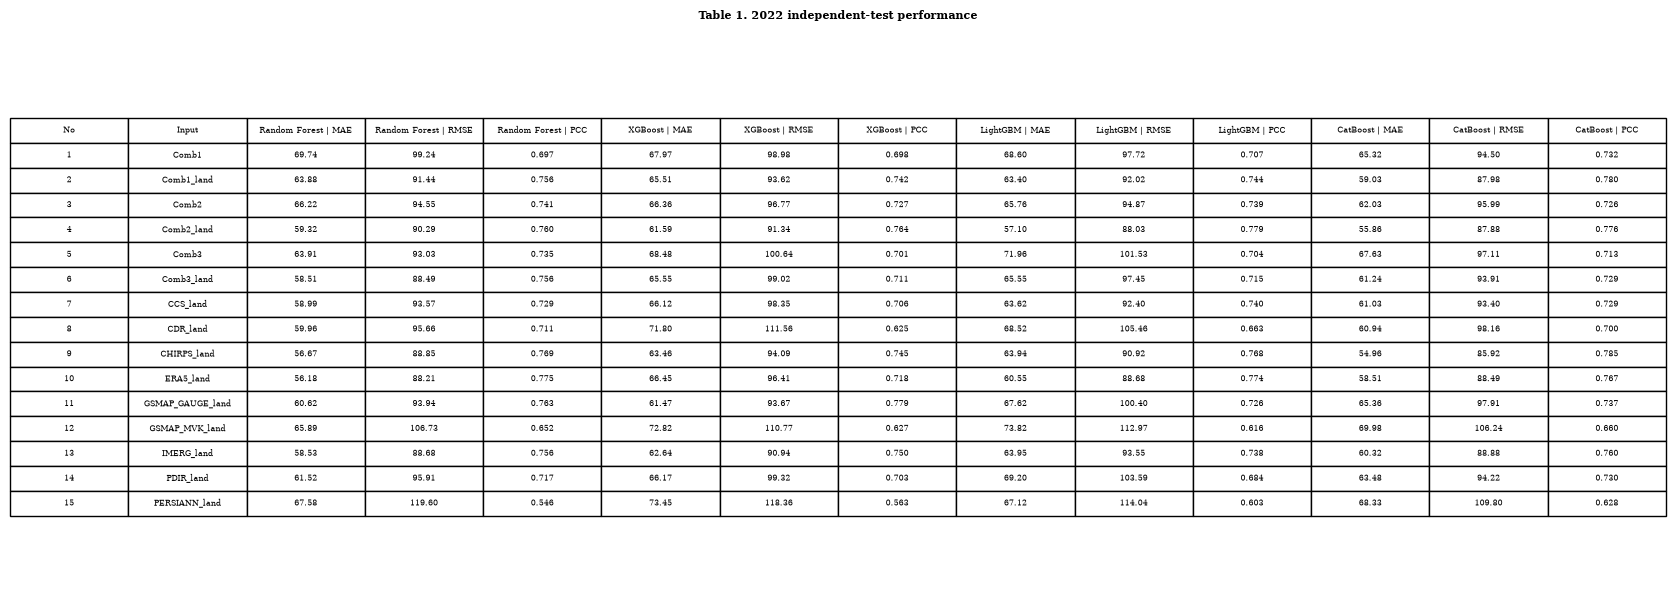

In [12]:
model_order=[m for m in ["Cubist","Random Forest","XGBoost","LightGBM","CatBoost"] if m in results_long.Model.unique()]
input_order=[x for x in COMBINATIONS if x in results_long.Input.unique()]

rows=[]
for i,inp in enumerate(input_order,1):
    rec={"No":i,"Input":inp}
    for model in model_order:
        r=results_long[(results_long.Input==inp)&(results_long.Model==model)]
        for metric in ["MAE","RMSE","PCC"]:
            rec[f"{model} | {metric}"]=float(r.iloc[0][metric]) if len(r) else np.nan
    rows.append(rec)
table1=pd.DataFrame(rows)
table1.to_csv(TABLE_DIR/"Table_1_paper_style.csv",index=False)

fig,ax=plt.subplots(figsize=(max(12,1.2*len(table1.columns)),max(5,.34*(len(table1)+3))))
ax.axis("off")
fmt=table1.copy()
for c in fmt.columns:
    if c not in ["No","Input"]:
        fmt[c]=fmt[c].map(lambda x:"" if pd.isna(x) else (f"{x:.3f}" if c.endswith("PCC") else f"{x:.2f}"))
tbl=ax.table(cellText=fmt.values,colLabels=fmt.columns,cellLoc="center",loc="center")
tbl.auto_set_font_size(False);tbl.set_fontsize(6);tbl.scale(1,1.25)
ax.set_title("Table 1. 2022 independent-test performance",fontweight="bold",pad=12)
fig.tight_layout()
fig.savefig(TABLE_DIR/"Table_1_paper_style.png",dpi=FIG_DPI,bbox_inches="tight")
fig.savefig(TABLE_DIR/"Table_1_paper_style.pdf",bbox_inches="tight")
plt.show()


## 8. Spatial station MAE / RMSE / PCC


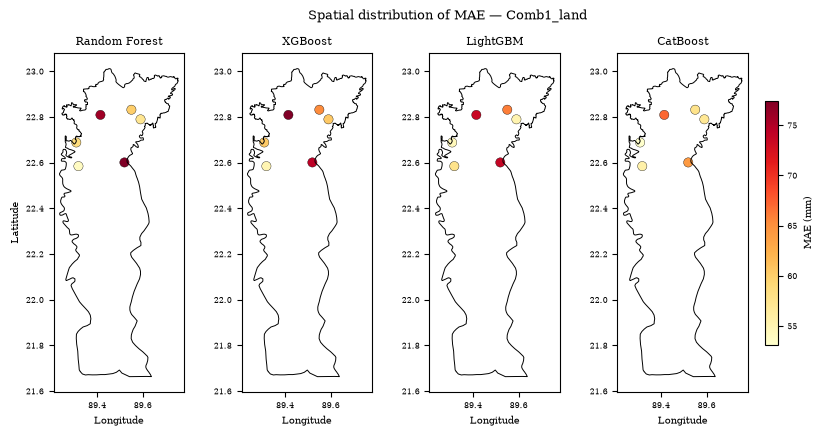

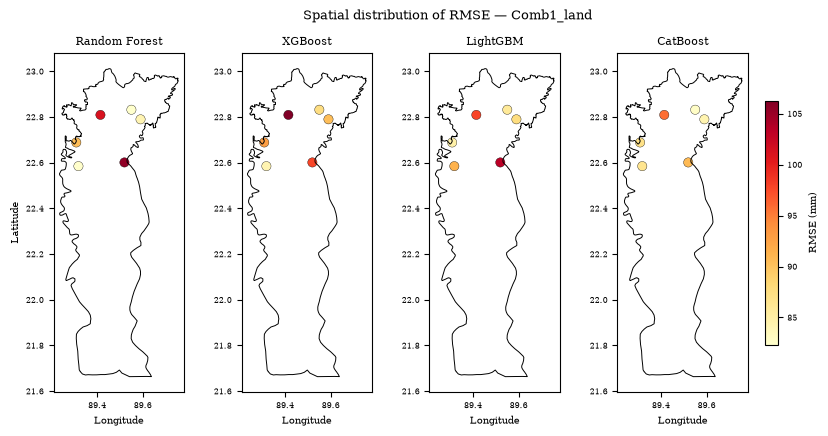

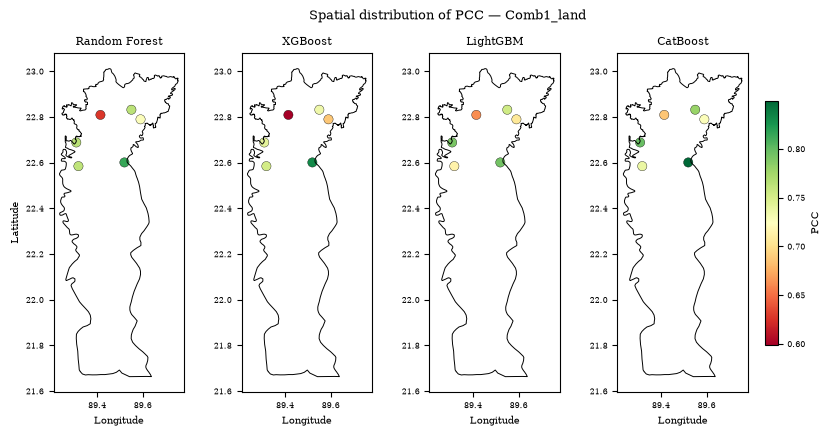

In [13]:
SPATIAL_COMBO=next((c for c in ["Comb1_land","Comb2_land","Comb1"] if c in COMBINATIONS),None)

def station_metric_table(combo,model):
    b=trained[(combo,model)]
    d=b["test_frame"].copy()
    d["prediction"]=b["pred_test"]
    key="station_id" if "station_id" in d.columns else ("station" if "station" in d.columns else None)
    if key is None:
        d["_key"]=d.latitude.round(5).astype(str)+"_"+d.longitude.round(5).astype(str)
        key="_key"
    rr=[]
    for sid,g in d.groupby(key):
        mm=metric_dict(g[TARGET],g.prediction)
        rr.append({"station":sid,"latitude":g.latitude.iloc[0],"longitude":g.longitude.iloc[0],**mm})
    return pd.DataFrame(rr)

station_tables={}
for model in model_order:
    if (SPATIAL_COMBO,model) in trained:
        station_tables[model]=station_metric_table(SPATIAL_COMBO,model)
        station_tables[model].to_csv(TABLE_DIR/f"station_metrics_{SPATIAL_COMBO}_{model.replace(' ','_')}.csv",index=False)

def plot_station_metric(metric,stem,cmap):
    names=list(station_tables)
    vals=np.concatenate([station_tables[m][metric].dropna().values for m in names])
    vmin,vmax=np.nanpercentile(vals,[2,98])

    fig,axes=plt.subplots(1,len(names),figsize=(2.8*len(names),4.4),squeeze=False)
    sc=None
    for j,m in enumerate(names):
        ax=axes[0,j]
        boundary.boundary.plot(ax=ax,color="black",linewidth=.7)
        t=station_tables[m]
        sc=ax.scatter(t.longitude,t.latitude,c=t[metric],cmap=cmap,vmin=vmin,vmax=vmax,
                      s=45,edgecolor="black",linewidth=.25)
        ax.set_title(m)
        ax.set_aspect("equal")
        ax.set_xlabel("Longitude")
        if j==0:ax.set_ylabel("Latitude")
    cb=fig.colorbar(sc,ax=axes.ravel().tolist(),shrink=.72,pad=.02)
    cb.set_label(metric+(" (mm)" if metric in ["MAE","RMSE"] else ""))
    fig.suptitle(f"Spatial distribution of {metric} — {SPATIAL_COMBO}")
    fig.savefig(FIG_DIR/f"{stem}.png",dpi=FIG_DPI,bbox_inches="tight")
    fig.savefig(FIG_DIR/f"{stem}.pdf",bbox_inches="tight")
    plt.show()

plot_station_metric("MAE","Fig_3_spatial_MAE","YlOrRd")
plot_station_metric("RMSE","Fig_4_spatial_RMSE","YlOrRd")
plot_station_metric("PCC","Fig_5_spatial_PCC","RdYlGn")


## 9. PROJ-free raster resampling

This replaces `rasterio.warp.reproject`.

Because all rasters used for the final map are already geographic WGS84, target pixel-center lon/lat coordinates are converted directly to source row/column coordinates using each raster's affine transform. Bilinear sampling is then performed with SciPy.


In [14]:
def feature_path(feature,year,month):
    if feature in precip_folders or feature in MONTHLY_LAND:
        return monthly_path(feature,year,month)
    return static_land.get(feature)

def fill_nodata_nearest(a):
    valid=np.isfinite(a)
    if not valid.any():
        return a
    if valid.all():
        return a
    idx=distance_transform_edt(~valid,return_distances=False,return_indices=True)
    return a[tuple(idx)]

def sample_raster_to_target_projfree(path,order=1):
    if path is None or not Path(path).exists():
        return None

    with rasterio.open(path) as src:
        wkt=(src.crs.wkt if src.crs else "").upper()
        is_geo=("GEOGCS" in wkt or "GEOGCRS" in wkt) and "WGS 84" in wkt
        if not is_geo:
            raise ValueError(f"Non-WGS84 raster cannot be used without PROJ: {path}")

        a=src.read(1).astype("float32")
        if src.nodata is not None:
            a[np.isclose(a,src.nodata,equal_nan=True)]=np.nan
        a[np.abs(a)>1e30]=np.nan

        # Fill source internal NoData before interpolation, but preserve outside extent as NaN.
        af=fill_nodata_nearest(a)

        inv=~src.transform
        cols,rows=inv*(TG_LON,TG_LAT)

        inside=(rows>=0)&(rows<=src.height-1)&(cols>=0)&(cols<=src.width-1)
        out=np.full(TARGET_SHAPE,np.nan,dtype="float32")

        coords=np.vstack([rows[inside],cols[inside]])
        out[inside]=map_coordinates(af,coords,order=order,mode="nearest").astype("float32")
        out[~TARGET_MASK]=np.nan
        return out

def write_masked_tif(path,arr,reference_path):
    path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
    out=np.where(np.isfinite(arr)&TARGET_MASK,arr,NODATA).astype("float32")

    # Reuse the WKT stored in a working source raster; no EPSG database lookup.
    with rasterio.open(reference_path) as ref:
        ref_crs=ref.crs

    profile={
        "driver":"GTiff","height":TARGET_HEIGHT,"width":TARGET_WIDTH,"count":1,
        "dtype":"float32","crs":ref_crs,"transform":TARGET_TRANSFORM,
        "nodata":NODATA,"compress":"LZW","tiled":True
    }
    with rasterio.open(path,"w",**profile) as dst:
        dst.write(out,1)

def predict_month(bundle,year,month):
    arrays=[]
    missing=[]

    for f in bundle["features"]:
        p=feature_path(f,year,month)
        if p is None or not Path(p).exists():
            missing.append(f)
            continue

        a=sample_raster_to_target_projfree(p,order=1)
        if a is None:
            missing.append(f)
            continue

        if f=="NDVI":
            finite=a[np.isfinite(a)]
            if finite.size and np.nanpercentile(np.abs(finite),95)>2:
                a*=0.0001

        if f in precip_folders:
            a[a<0]=np.nan

        arrays.append((f,a))

    if missing:
        return None,"missing file: "+", ".join(missing)

    X=np.column_stack([a.ravel() for _,a in arrays])
    valid=np.all(np.isfinite(X),axis=1)&TARGET_MASK.ravel()

    if valid.sum()==0:
        return None,"no common valid target pixels"

    pred=np.full(TARGET_SHAPE,np.nan,dtype="float32")
    pred.ravel()[valid]=np.maximum(bundle["estimator"].predict(X[valid]),0).astype("float32")
    pred[~TARGET_MASK]=np.nan
    return pred,"OK"


## 10. Generate all 2022 monthly masked GeoTIFFs


In [15]:
MAP_COMBOS=[c for c in ["Comb1","Comb1_land","Comb2_land"] if c in COMBINATIONS]
if len(MAP_COMBOS)<3:
    for c in COMBINATIONS:
        if c not in MAP_COMBOS:
            MAP_COMBOS.append(c)
        if len(MAP_COMBOS)==3:break

MAP_MODELS=[m for m in ["Cubist","Random Forest","XGBoost","LightGBM","CatBoost"] if m in model_order]

# A guaranteed WGS84 monthly raster for output CRS metadata.
REFERENCE_TIF=None
for name in precip_products:
    REFERENCE_TIF=monthly_path(name,TEST_YEAR,1)
    if REFERENCE_TIF:break
if REFERENCE_TIF is None:
    raise FileNotFoundError("No 2022 reference precipitation raster found.")

generated={}   # (combo,model,month) -> Path
map_qa=[]

for combo in MAP_COMBOS:
    for model in MAP_MODELS:
        if (combo,model) not in trained:continue
        b=trained[(combo,model)]
        out_dir=MAP_DIR/combo/model.replace(" ","_")
        out_dir.mkdir(parents=True,exist_ok=True)

        print("Predicting:",combo,"|",model)

        for month in range(1,13):
            out_tif=out_dir/f"downscaled_{TEST_YEAR}_{month:02d}.tif"

            if out_tif.exists():
                generated[(combo,model,month)]=out_tif
                map_qa.append({"combo":combo,"model":model,"month":month,"status":"EXISTS","reason":""})
                continue

            try:
                pred,status=predict_month(b,TEST_YEAR,month)
                if pred is None:
                    map_qa.append({"combo":combo,"model":model,"month":month,"status":"SKIP","reason":status})
                    print("  skip",month,status)
                    continue

                write_masked_tif(out_tif,pred,REFERENCE_TIF)
                generated[(combo,model,month)]=out_tif
                map_qa.append({"combo":combo,"model":model,"month":month,"status":"OK","reason":""})
            except Exception as e:
                map_qa.append({"combo":combo,"model":model,"month":month,"status":"ERROR","reason":repr(e)})
                print("  ERROR",month,repr(e))

map_qa=pd.DataFrame(map_qa)
map_qa.to_csv(QA_DIR/"map_generation_QA.csv",index=False)
display(map_qa[~map_qa.status.isin(["OK","EXISTS"])])

summary=map_qa.groupby(["combo","model"])["status"].apply(lambda x:x.isin(["OK","EXISTS"]).sum()).rename("months_generated").reset_index()
display(summary)


Predicting: Comb1 | Random Forest
Predicting: Comb1 | XGBoost
Predicting: Comb1 | LightGBM
Predicting: Comb1 | CatBoost
Predicting: Comb1_land | Random Forest
Predicting: Comb1_land | XGBoost
Predicting: Comb1_land | LightGBM
Predicting: Comb1_land | CatBoost
Predicting: Comb2_land | Random Forest
Predicting: Comb2_land | XGBoost
Predicting: Comb2_land | LightGBM
Predicting: Comb2_land | CatBoost


,combo,model,month,status,reason


,combo,model,months_generated
0,Comb1,CatBoost,12
1,Comb1,LightGBM,12
2,Comb1,Random Forest,12
3,Comb1,XGBoost,12
4,Comb1_land,CatBoost,12
5,Comb1_land,LightGBM,12
6,Comb1_land,Random Forest,12
7,Comb1_land,XGBoost,12
8,Comb2_land,CatBoost,12
9,Comb2_land,LightGBM,12


## 11. Resolution + mask QA


In [16]:
qa=[]
for name,idx in precip_index.items():
    if idx:
        p=next(iter(idx.values()))
        with rasterio.open(p) as src:
            qa.append({"dataset":name,"kind":"precipitation","xres":abs(src.res[0]),"yres":abs(src.res[1]),"crs_wkt_head":(src.crs.wkt[:80] if src.crs else "")})

for name in MONTHLY_LAND:
    idx=predictor_index.get(name,{})
    if idx:
        p=next(iter(idx.values()))
        with rasterio.open(p) as src:
            qa.append({"dataset":name,"kind":"monthly land","xres":abs(src.res[0]),"yres":abs(src.res[1]),"crs_wkt_head":(src.crs.wkt[:80] if src.crs else "")})

for name,p in static_land.items():
    with rasterio.open(p) as src:
        qa.append({"dataset":name,"kind":"static land","xres":abs(src.res[0]),"yres":abs(src.res[1]),"crs_wkt_head":(src.crs.wkt[:80] if src.crs else "")})

qa.append({"dataset":"FINAL_ML_OUTPUT","kind":"statistical downscaling grid","xres":TARGET_RES_DEG,"yres":TARGET_RES_DEG,"crs_wkt_head":"WGS84 geographic"})
qa_df=pd.DataFrame(qa)
display(qa_df)
qa_df.to_csv(QA_DIR/"resolution_QA.csv",index=False)

sample=next(iter(generated.values()),None)
if sample:
    with rasterio.open(sample) as src:
        a=src.read(1)
        outside_ok=np.all(a[~TARGET_MASK]==src.nodata)
        print("Sample output:",sample)
        print("Resolution:",src.res)
        print("Outside Khulna = NoData:",outside_ok)


,dataset,kind,xres,yres,crs_wkt_head
0,CCS,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
1,CDR,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
2,CHIRPS,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
3,ERA5,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
4,GSMAP_GAUGE,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
5,GSMAP_MVK,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
6,IMERG,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
7,PDIR,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
8,PERSIANN,precipitation,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
9,NDVI,monthly land,0.008983,0.008983,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."


Sample output: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final\monthly_masked_highres_tif\Comb1\Random_Forest\downscaled_2022_01.tif
Resolution: (0.005, 0.005)
Outside Khulna = NoData: True


## 12. Observed vs predicted best model


Total combinations: 15
['Comb1', 'Comb1_land', 'Comb2', 'Comb2_land', 'Comb3', 'Comb3_land', 'CCS_land', 'CDR_land', 'CHIRPS_land', 'ERA5_land', 'GSMAP_GAUGE_land', 'GSMAP_MVK_land', 'IMERG_land', 'PDIR_land', 'PERSIANN_land']

PLOTTING: Comb1


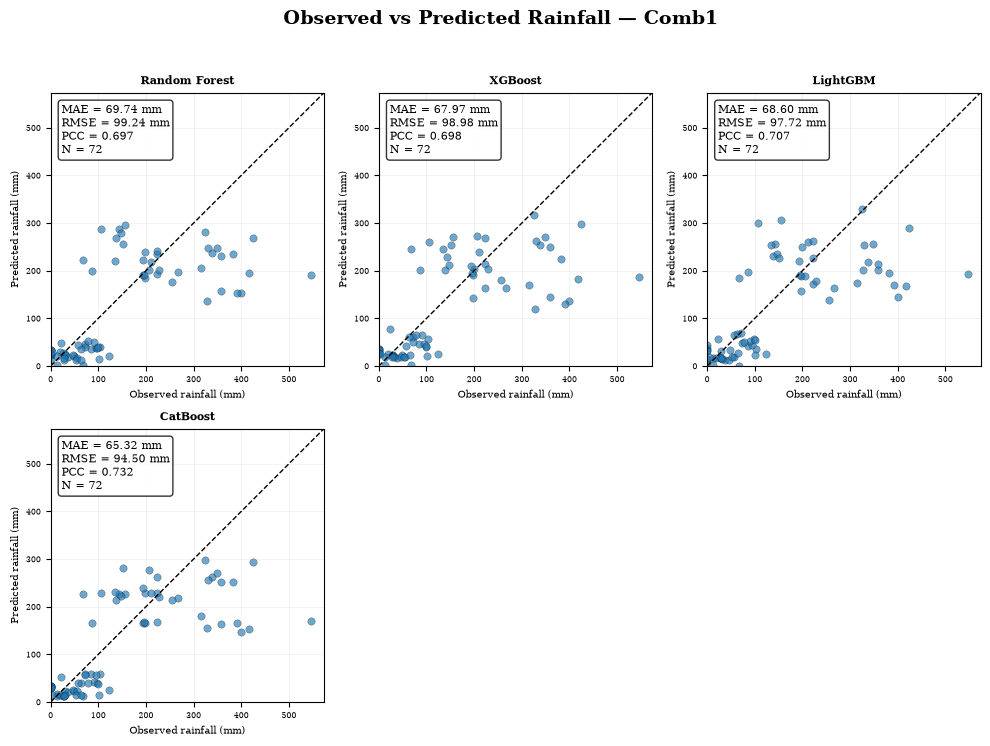


PLOTTING: Comb1_land


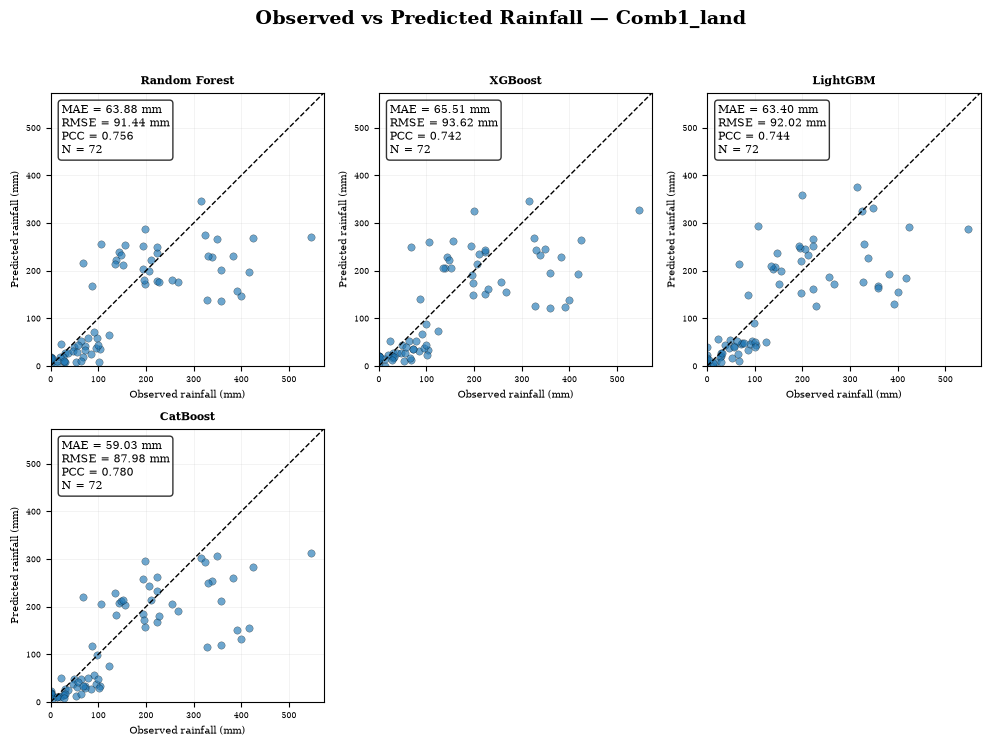


PLOTTING: Comb2


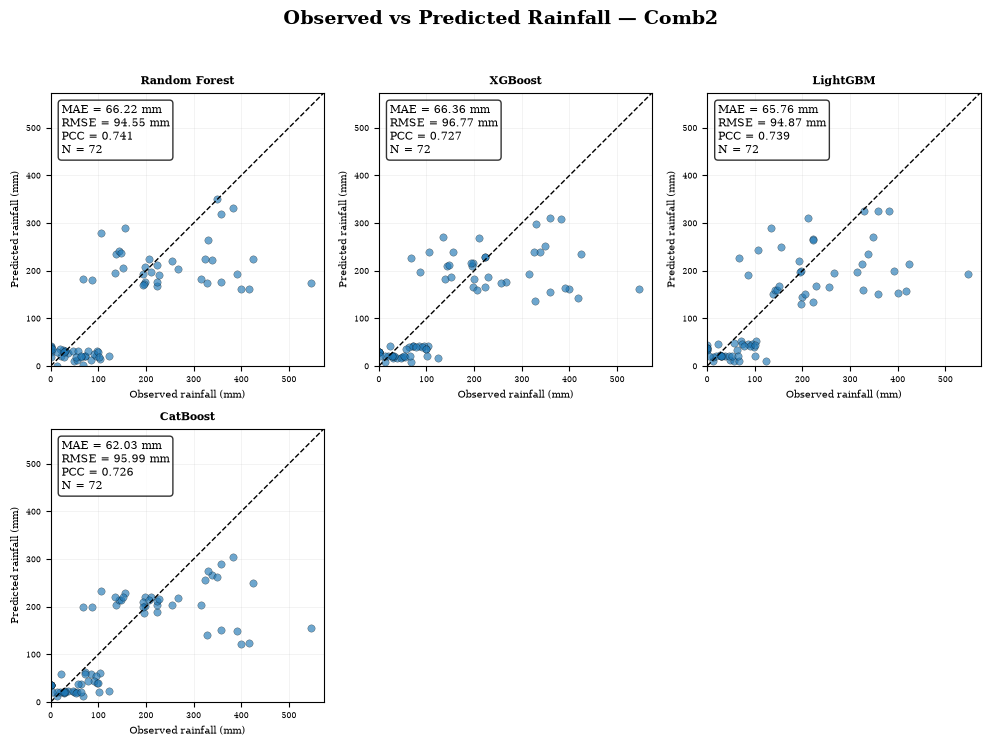


PLOTTING: Comb2_land


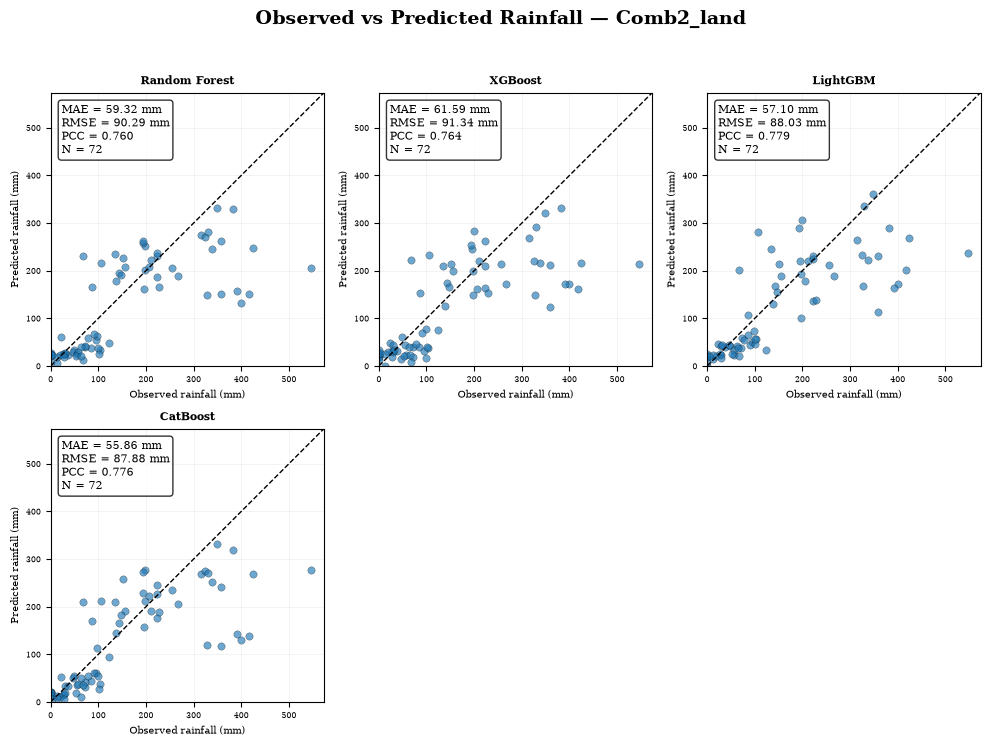


PLOTTING: Comb3


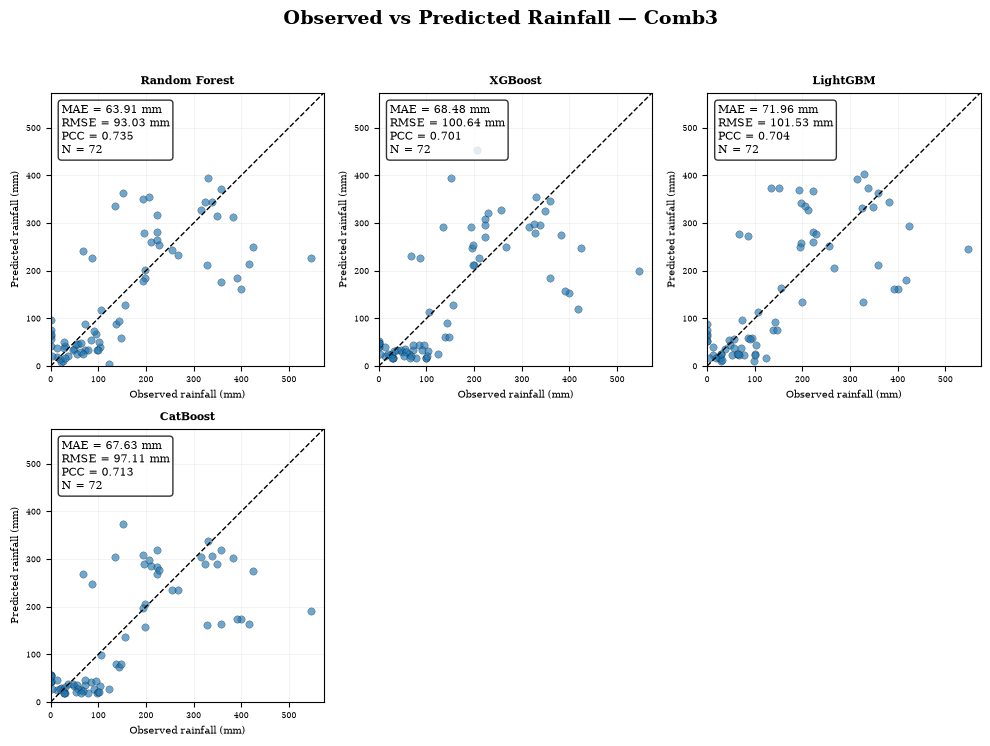


PLOTTING: Comb3_land


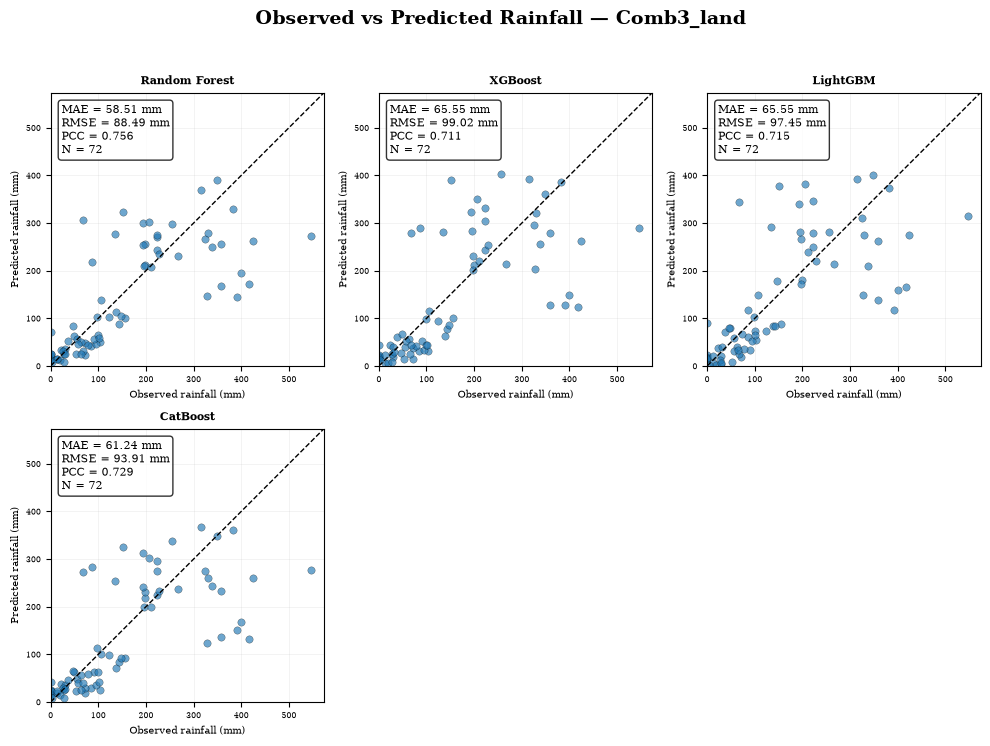


PLOTTING: CCS_land


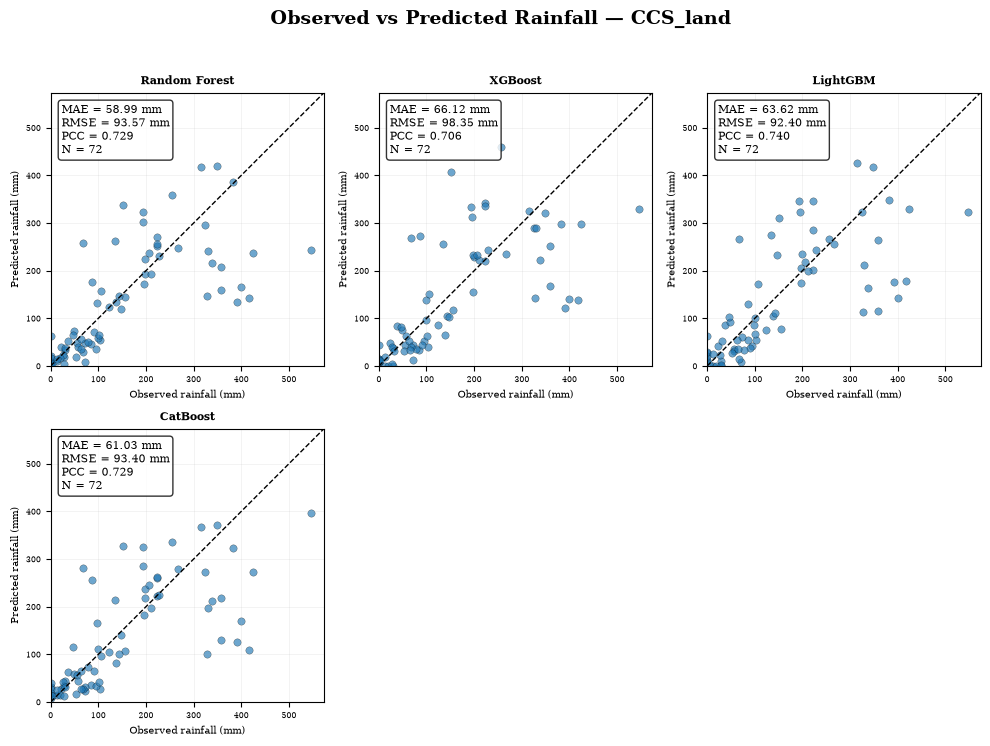


PLOTTING: CDR_land


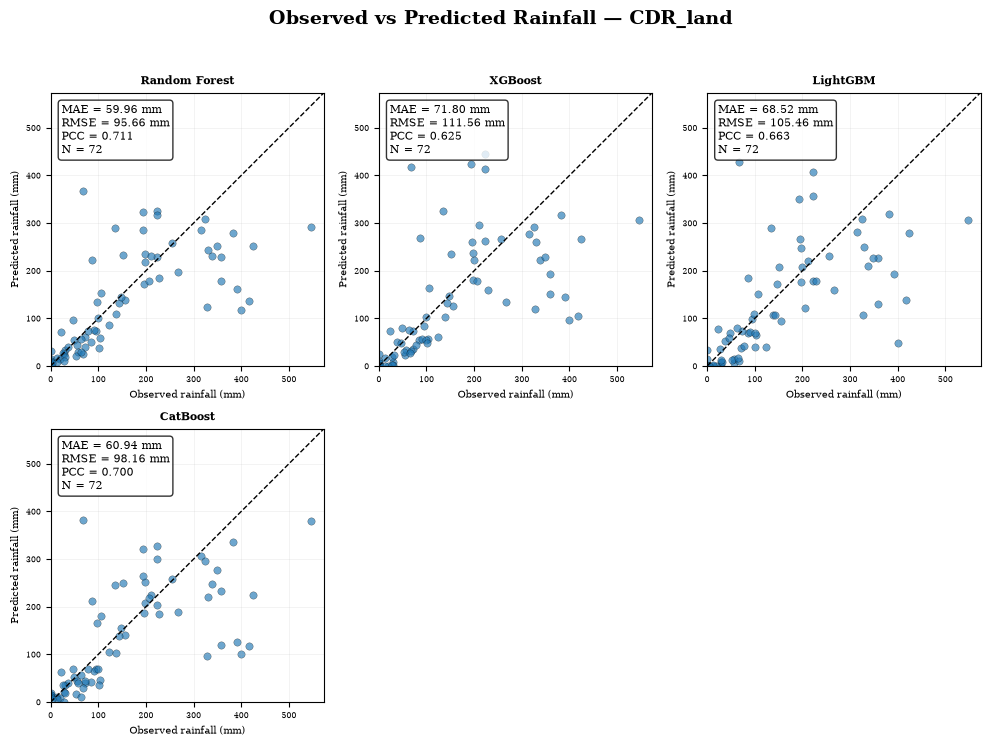


PLOTTING: CHIRPS_land


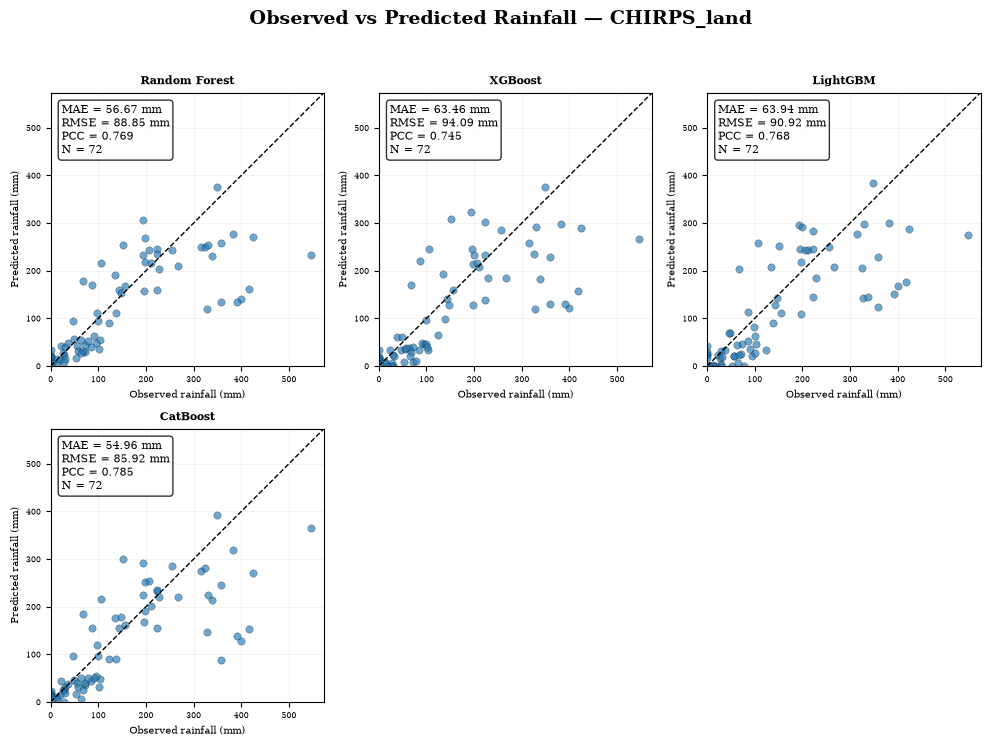


PLOTTING: ERA5_land


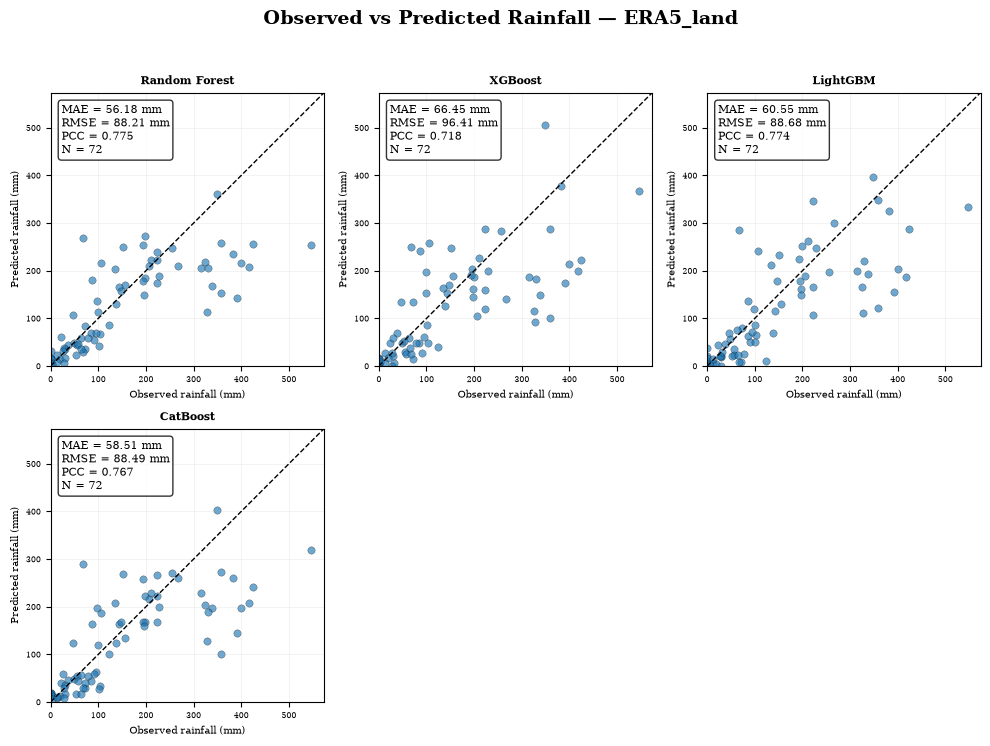


PLOTTING: GSMAP_GAUGE_land


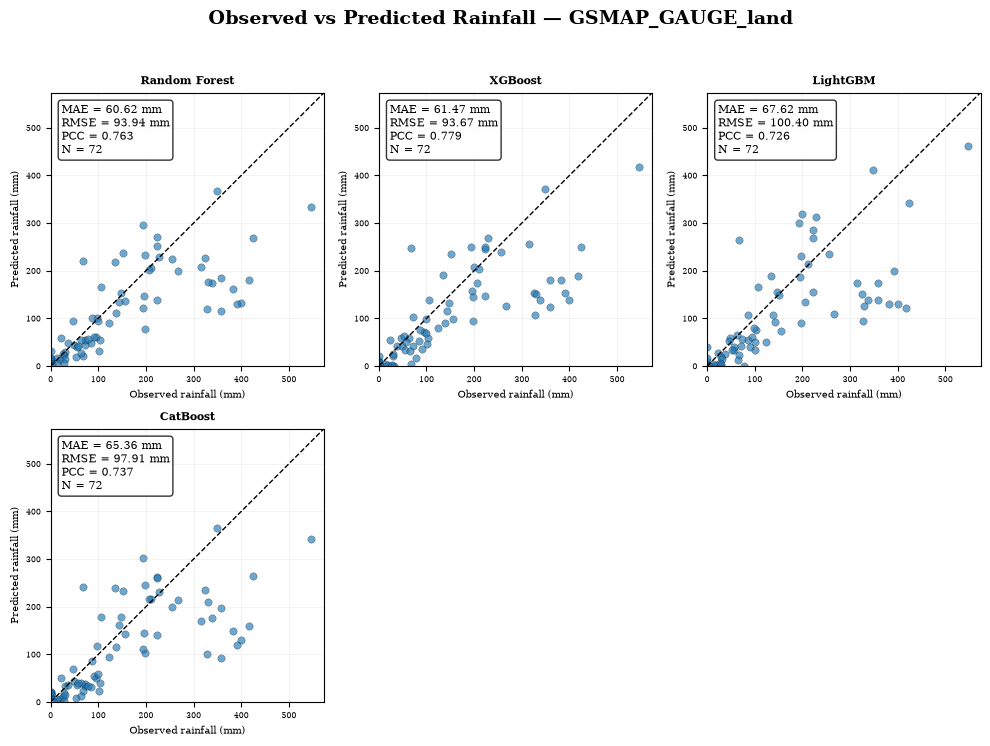


PLOTTING: GSMAP_MVK_land


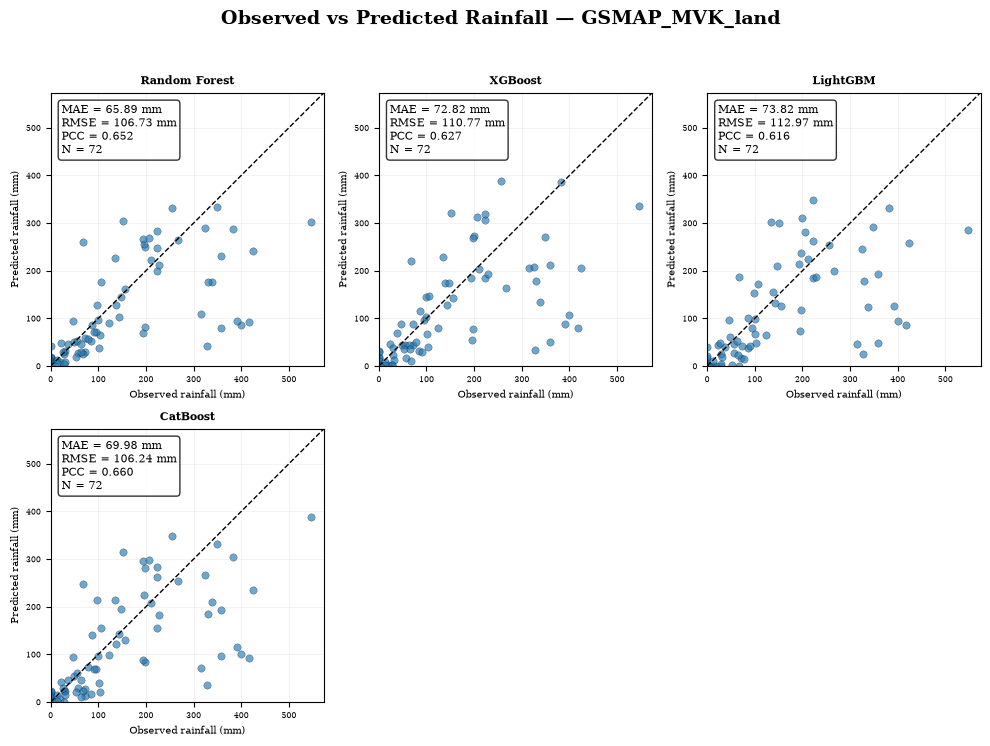


PLOTTING: IMERG_land


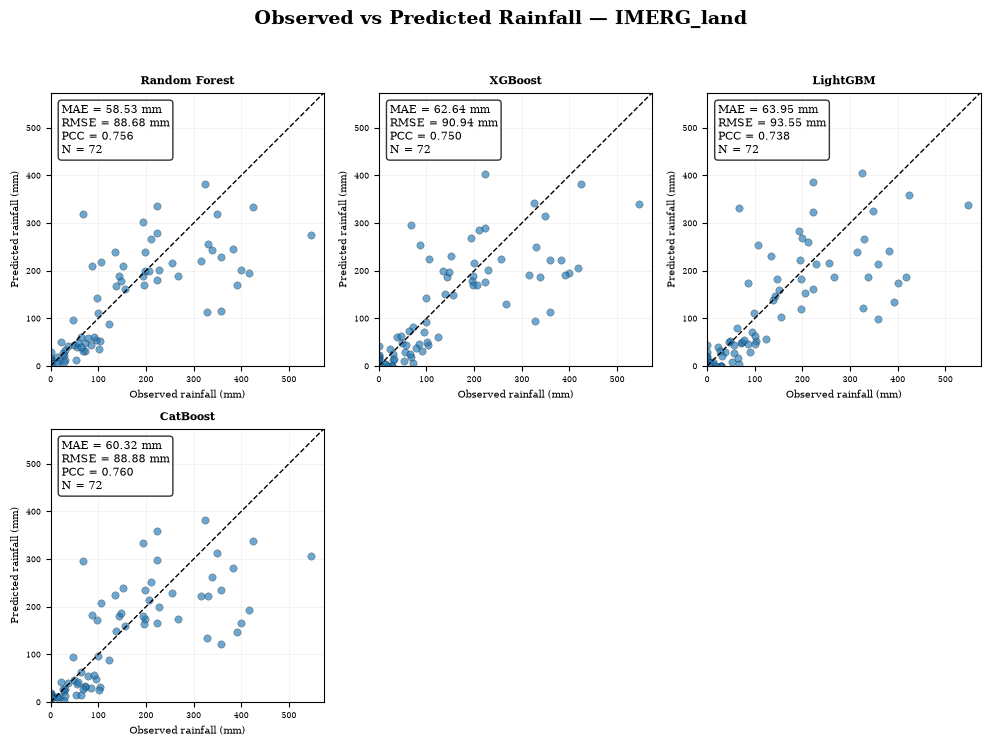


PLOTTING: PDIR_land


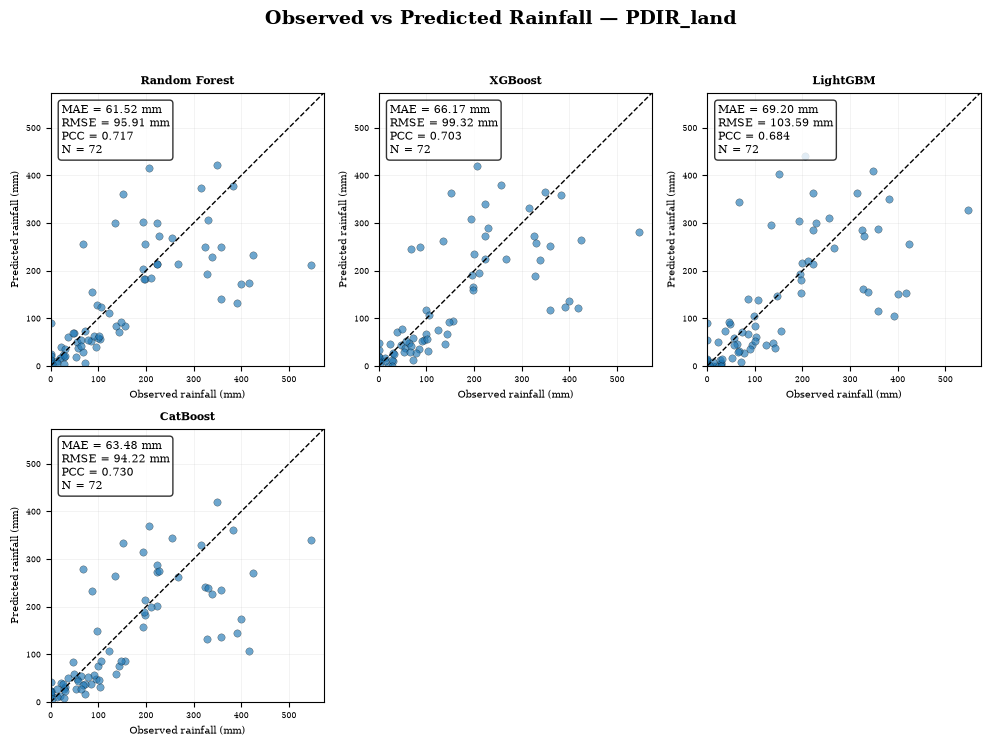


PLOTTING: PERSIANN_land


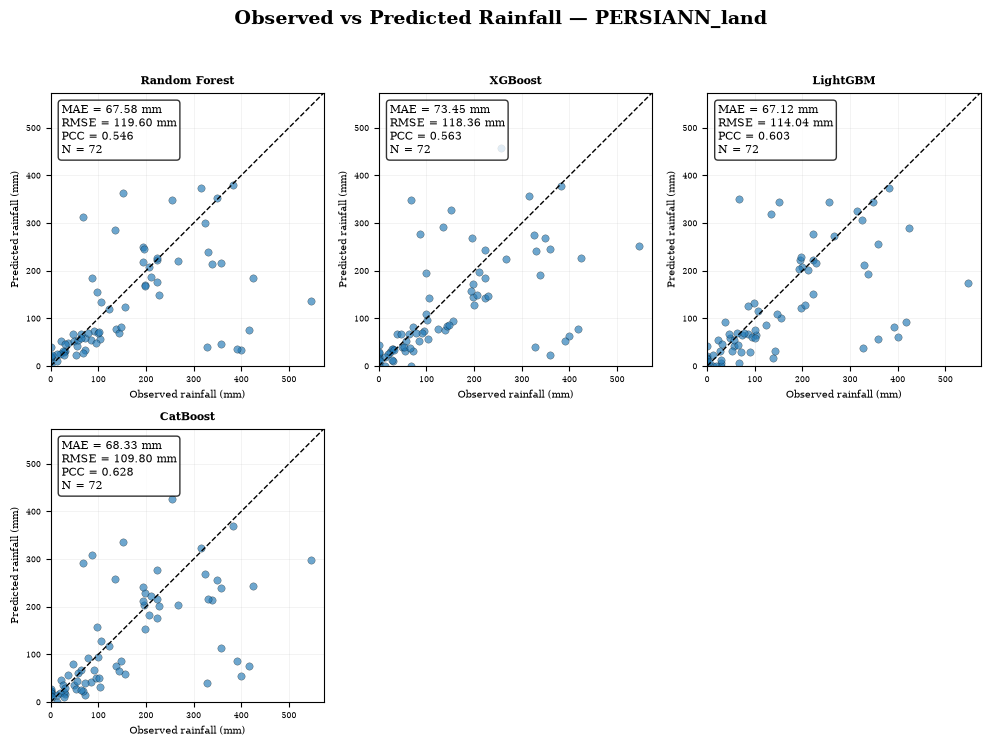

,Input,Model,MAE,RMSE,PCC,N_test,Rank_within_Input
0,CCS_land,LightGBM,63.617387,92.399317,0.739887,72,1
1,CCS_land,CatBoost,61.031327,93.403978,0.728757,72,2
2,CCS_land,Random Forest,58.985157,93.566772,0.728556,72,3
3,CCS_land,XGBoost,66.117078,98.350217,0.705576,72,4
4,CDR_land,Random Forest,59.959644,95.663491,0.710892,72,1
5,CDR_land,CatBoost,60.941954,98.159089,0.700474,72,2
6,CDR_land,LightGBM,68.524673,105.455426,0.663328,72,3
7,CDR_land,XGBoost,71.799302,111.555119,0.624982,72,4
8,CHIRPS_land,CatBoost,54.961706,85.919267,0.785114,72,1
9,CHIRPS_land,Random Forest,56.671925,88.850461,0.768550,72,2



BEST MODEL FOR EACH INPUT COMBINATION


,Input,Model,MAE,RMSE,PCC,N_test
0,CCS_land,LightGBM,63.617387,92.399317,0.739887,72
1,CDR_land,Random Forest,59.959644,95.663491,0.710892,72
2,CHIRPS_land,CatBoost,54.961706,85.919267,0.785114,72
3,Comb1,CatBoost,65.319413,94.504846,0.731530,72
4,Comb1_land,CatBoost,59.029316,87.983621,0.780027,72
5,Comb2,Random Forest,66.215792,94.551713,0.740961,72
6,Comb2_land,CatBoost,55.862721,87.883396,0.775773,72
7,Comb3,Random Forest,63.912698,93.034438,0.734858,72
8,Comb3_land,Random Forest,58.512736,88.491125,0.756437,72
9,ERA5_land,Random Forest,56.181869,88.208430,0.775043,72



OVERALL BEST MODEL
Input combination : CHIRPS_land
Model             : CatBoost
MAE               : 54.96 mm
RMSE              : 85.92 mm
PCC               : 0.785
N test            : 72


In [21]:
# ============================================================
# OBSERVED vs PREDICTED
# ALL INPUT COMBINATIONS × ALL MODELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ------------------------------------------------------------
# Model order
# ------------------------------------------------------------
MODEL_ORDER = [
    "Cubist",
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

# Keep combination order from COMBINATIONS
ALL_COMBOS = [
    combo for combo in COMBINATIONS.keys()
    if any((combo, model) in trained for model in MODEL_ORDER)
]

print("Total combinations:", len(ALL_COMBOS))
print(ALL_COMBOS)


# ============================================================
# Function: plot all models for ONE combination
# ============================================================

def plot_all_models_for_combo(combo):

    models = [
        model for model in MODEL_ORDER
        if (combo, model) in trained
    ]

    if len(models) == 0:
        print("No trained model:", combo)
        return None

    # --------------------------------------------------------
    # Common axis range
    # --------------------------------------------------------
    values = []

    for model in models:

        b = trained[(combo, model)]

        obs = np.asarray(
            b["y_test"],
            dtype=float
        )

        pred = np.asarray(
            b["pred_test"],
            dtype=float
        )

        values.extend(
            obs[np.isfinite(obs)]
        )

        values.extend(
            pred[np.isfinite(pred)]
        )

    values = np.asarray(values)

    lo = max(
        0,
        np.nanmin(values)
    )

    hi = np.nanmax(values)

    pad = (
        (hi - lo) * 0.05
        if hi > lo
        else 1
    )

    plot_lo = max(
        0,
        lo - pad
    )

    plot_hi = hi + pad


    # ========================================================
    # Figure layout
    # ========================================================

    if len(models) == 5:

        fig = plt.figure(
            figsize=(12, 7.5)
        )

        positions = [

            # Top row
            [0.06, 0.55, 0.26, 0.34],
            [0.37, 0.55, 0.26, 0.34],
            [0.68, 0.55, 0.26, 0.34],

            # Bottom row
            [0.21, 0.08, 0.26, 0.34],
            [0.53, 0.08, 0.26, 0.34],

        ]

        axes = [
            fig.add_axes(pos)
            for pos in positions
        ]

    else:

        ncols = min(
            3,
            len(models)
        )

        nrows = int(
            np.ceil(
                len(models) / ncols
            )
        )

        fig, axs = plt.subplots(
            nrows,
            ncols,
            figsize=(
                4 * ncols,
                4 * nrows
            )
        )

        axes = np.atleast_1d(
            axs
        ).ravel()

        for ax in axes[len(models):]:
            ax.axis("off")


    # ========================================================
    # Plot every model
    # ========================================================

    rows = []

    for ax, model in zip(
        axes,
        models
    ):

        b = trained[
            (combo, model)
        ]

        y_obs = np.asarray(
            b["y_test"],
            dtype=float
        )

        y_pred = np.asarray(
            b["pred_test"],
            dtype=float
        )

        valid = (
            np.isfinite(y_obs)
            &
            np.isfinite(y_pred)
        )

        y_obs = y_obs[valid]
        y_pred = y_pred[valid]


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_obs,
            y_pred
        )

        rmse = (
            mean_squared_error(
                y_obs,
                y_pred
            ) ** 0.5
        )

        pcc_value = pcc(
            y_obs,
            y_pred
        )


        rows.append({

            "Input": combo,

            "Model": model,

            "MAE": mae,

            "RMSE": rmse,

            "PCC": pcc_value,

            "N_test": len(y_obs)

        })


        # ----------------------------------------------------
        # Scatter
        # ----------------------------------------------------

        ax.scatter(

            y_obs,

            y_pred,

            s=28,

            alpha=0.65,

            edgecolors="black",

            linewidths=0.25

        )


        # ----------------------------------------------------
        # 1:1 line
        # ----------------------------------------------------

        ax.plot(

            [plot_lo, plot_hi],

            [plot_lo, plot_hi],

            "--",

            color="black",

            linewidth=1

        )


        ax.set_xlim(
            plot_lo,
            plot_hi
        )

        ax.set_ylim(
            plot_lo,
            plot_hi
        )

        ax.set_aspect(
            "equal",
            adjustable="box"
        )


        ax.set_xlabel(
            "Observed rainfall (mm)"
        )

        ax.set_ylabel(
            "Predicted rainfall (mm)"
        )


        ax.set_title(

            model,

            fontweight="bold"

        )


        # ----------------------------------------------------
        # Metrics box
        # ----------------------------------------------------

        txt = (

            f"MAE = {mae:.2f} mm\n"

            f"RMSE = {rmse:.2f} mm\n"

            f"PCC = {pcc_value:.3f}\n"

            f"N = {len(y_obs)}"

        )


        ax.text(

            0.04,

            0.96,

            txt,

            transform=ax.transAxes,

            ha="left",

            va="top",

            fontsize=8,

            bbox=dict(

                boxstyle="round",

                facecolor="white",

                alpha=0.80

            )

        )


        ax.grid(
            alpha=0.20,
            linewidth=0.5
        )


    # ========================================================
    # Main title
    # ========================================================

    fig.suptitle(

        f"Observed vs Predicted Rainfall — {combo}",

        fontsize=14,

        fontweight="bold",

        y=0.98

    )


    # ========================================================
    # Save figure
    # ========================================================

    png_path = (
        FIG_DIR /
        f"Observed_vs_Predicted_{combo}_ALL_MODELS.png"
    )

    pdf_path = (
        FIG_DIR /
        f"Observed_vs_Predicted_{combo}_ALL_MODELS.pdf"
    )


    fig.savefig(

        png_path,

        dpi=FIG_DPI,

        bbox_inches="tight"

    )


    fig.savefig(

        pdf_path,

        bbox_inches="tight"

    )


    plt.show()

    plt.close(fig)


    return pd.DataFrame(rows)


# ============================================================
# RUN FOR EVERY COMBINATION
# ============================================================

all_comparison_tables = []


for combo in ALL_COMBOS:

    print("\n" + "=" * 70)

    print(
        "PLOTTING:",
        combo
    )

    print("=" * 70)


    result = plot_all_models_for_combo(
        combo
    )


    if result is not None:

        all_comparison_tables.append(
            result
        )


# ============================================================
# COMBINE ALL RESULTS
# ============================================================

all_model_comparison = pd.concat(

    all_comparison_tables,

    ignore_index=True

)


# ============================================================
# Rank models WITHIN each input combination
# ============================================================

all_model_comparison["Rank_within_Input"] = (

    all_model_comparison

    .groupby("Input")["RMSE"]

    .rank(
        method="min",
        ascending=True
    )

    .astype(int)

)


all_model_comparison = (

    all_model_comparison

    .sort_values(
        [
            "Input",
            "Rank_within_Input",
            "RMSE"
        ]
    )

    .reset_index(drop=True)

)


display(
    all_model_comparison
)


# ============================================================
# SAVE FULL COMPARISON TABLE
# ============================================================

all_model_comparison.to_csv(

    TABLE_DIR /
    "Observed_vs_Predicted_ALL_COMBINATIONS_ALL_MODELS.csv",

    index=False

)


# ============================================================
# BEST MODEL FOR EACH INPUT
# ============================================================

best_each_input = (

    all_model_comparison

    .sort_values(
        [
            "Input",
            "RMSE",
            "MAE"
        ]
    )

    .groupby(
        "Input",
        as_index=False
    )

    .first()

)


print(
    "\nBEST MODEL FOR EACH INPUT COMBINATION"
)

display(
    best_each_input[
        [
            "Input",
            "Model",
            "MAE",
            "RMSE",
            "PCC",
            "N_test"
        ]
    ]
)


best_each_input.to_csv(

    TABLE_DIR /
    "Best_Model_for_Each_Input.csv",

    index=False

)


# ============================================================
# OVERALL BEST MODEL + INPUT
# ============================================================

overall_best = (

    all_model_comparison

    .sort_values(
        [
            "RMSE",
            "MAE"
        ]
    )

    .iloc[0]

)


print("\n" + "=" * 70)

print(
    "OVERALL BEST MODEL"
)

print("=" * 70)

print(
    f"Input combination : {overall_best['Input']}"
)

print(
    f"Model             : {overall_best['Model']}"
)

print(
    f"MAE               : {overall_best['MAE']:.2f} mm"
)

print(
    f"RMSE              : {overall_best['RMSE']:.2f} mm"
)

print(
    f"PCC               : {overall_best['PCC']:.3f}"
)

print(
    f"N test            : {int(overall_best['N_test'])}"
)

print("=" * 70)

# 13. FINAL — Annual rainfall maps

This is intentionally the final analytical section.

The annual map uses the `generated` dictionary from the monthly-map cell, so it cannot accidentally search a different folder and report `0/12` when monthly rasters were actually created.


,combo,model,status,missing_months
0,Comb1,Random Forest,OK,
1,Comb1_land,Random Forest,OK,
2,Comb2_land,Random Forest,OK,
3,Comb1,XGBoost,OK,
4,Comb1_land,XGBoost,OK,
5,Comb2_land,XGBoost,OK,
6,Comb1,LightGBM,OK,
7,Comb1_land,LightGBM,OK,
8,Comb2_land,LightGBM,OK,
9,Comb1,CatBoost,OK,


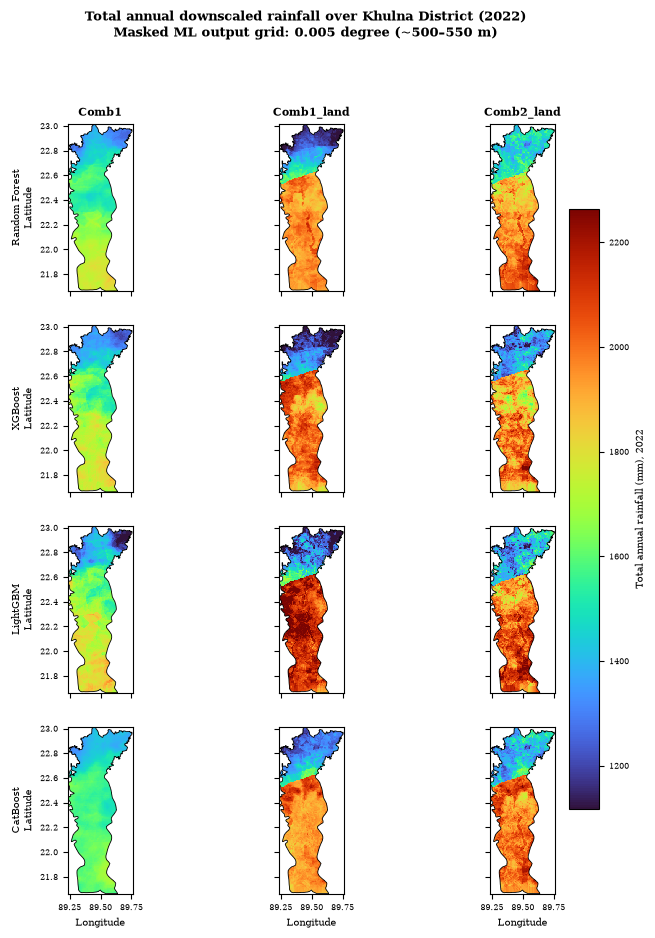

FINAL annual figure: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final\figures\FINAL_Annual_Rainfall_Paper_Style.png


In [18]:
def annual_from_generated(combo,model):
    paths=[generated.get((combo,model,m)) for m in range(1,13)]
    missing=[m+1 for m,p in enumerate(paths) if p is None or not Path(p).exists()]
    if missing:
        return None,missing

    stack=[]
    for p in paths:
        with rasterio.open(p) as src:
            a=src.read(1).astype("float32")
            if src.nodata is not None:
                a[a==src.nodata]=np.nan
            stack.append(a)

    stack=np.stack(stack)
    valid=np.all(np.isfinite(stack),axis=0)&TARGET_MASK
    annual=np.full(TARGET_SHAPE,np.nan,dtype="float32")
    annual[valid]=np.sum(stack[:,valid],axis=0)
    return annual,[]

annual={}
annual_rows=[]

for model in MAP_MODELS:
    for combo in MAP_COMBOS:
        if (combo,model) not in trained:continue

        a,missing=annual_from_generated(combo,model)
        if a is None:
            annual_rows.append({"combo":combo,"model":model,"status":"SKIP","missing_months":str(missing)})
            continue

        annual[(combo,model)]=a
        out_tif=ANNUAL_DIR/f"annual_{TEST_YEAR}_{combo}_{model.replace(' ','_')}.tif"
        write_masked_tif(out_tif,a,REFERENCE_TIF)
        annual_rows.append({"combo":combo,"model":model,"status":"OK","missing_months":""})

annual_qa=pd.DataFrame(annual_rows)
display(annual_qa)
annual_qa.to_csv(QA_DIR/"annual_generation_QA.csv",index=False)

vals=[]
for a in annual.values():
    vals.extend(a[np.isfinite(a)].ravel())

if not vals:
    print("No annual panel was created because no model/combination has all 12 monthly maps.")
    print("Open quality_control/map_generation_QA.csv to see the exact failing month/feature.")
else:
    vmin,vmax=np.nanpercentile(np.asarray(vals),[1,99])
    extent=[left,right,bottom,top]

    fig,axes=plt.subplots(len(MAP_MODELS),len(MAP_COMBOS),
                          figsize=(3.1*len(MAP_COMBOS),2.5*len(MAP_MODELS)),
                          squeeze=False)
    im=None
    for i,model in enumerate(MAP_MODELS):
        for j,combo in enumerate(MAP_COMBOS):
            ax=axes[i,j]
            a=annual.get((combo,model))

            if a is None:
                ax.axis("off")
                ax.text(.5,.5,"Not generated",ha="center",va="center",transform=ax.transAxes)
                continue

            im=ax.imshow(a,extent=extent,origin="upper",cmap="turbo",vmin=vmin,vmax=vmax,interpolation="nearest")
            boundary.boundary.plot(ax=ax,color="black",linewidth=.6)
            ax.set_aspect("equal")

            if i==0:ax.set_title(combo,fontweight="bold")
            if j==0:ax.set_ylabel(model+"\nLatitude")
            else:ax.set_yticklabels([])
            if i==len(MAP_MODELS)-1:ax.set_xlabel("Longitude")
            else:ax.set_xticklabels([])

    cb=fig.colorbar(im,ax=axes.ravel().tolist(),shrink=.78,pad=.02)
    cb.set_label(f"Total annual rainfall (mm), {TEST_YEAR}")
    fig.suptitle(
        f"Total annual downscaled rainfall over Khulna District ({TEST_YEAR})\n"
        f"Masked ML output grid: {TARGET_RES_DEG} degree (~500–550 m)",
        y=.995,fontweight="bold"
    )
    fig.savefig(FIG_DIR/"FINAL_Annual_Rainfall_Paper_Style.png",dpi=FIG_DPI,bbox_inches="tight")
    fig.savefig(FIG_DIR/"FINAL_Annual_Rainfall_Paper_Style.pdf",bbox_inches="tight")
    plt.show()

    print("FINAL annual figure:",FIG_DIR/"FINAL_Annual_Rainfall_Paper_Style.png")


In [19]:
manifest=[]
for folder in [TABLE_DIR,FIG_DIR,MAP_DIR,ANNUAL_DIR,QA_DIR,MODEL_DIR]:
    if folder.exists():
        for p in sorted(folder.rglob("*")):
            if p.is_file():
                manifest.append(str(p.relative_to(PROJECT_ROOT)))
pd.DataFrame({"output":manifest}).to_csv(OUT_ROOT/"output_manifest.csv",index=False)

print("DONE:",OUT_ROOT)
print("Important QA:")
print(" -",QA_DIR/"station_feature_missingness_after_edge_fix.csv")
print(" -",QA_DIR/"map_generation_QA.csv")
print(" -",QA_DIR/"annual_generation_QA.csv")
print(" -",QA_DIR/"resolution_QA.csv")


DONE: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final
Important QA:
 - E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final\quality_control\station_feature_missingness_after_edge_fix.csv
 - E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final\quality_control\map_generation_QA.csv
 - E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final\quality_control\annual_generation_QA.csv
 - E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_proj_free_final\qualit